# we have done with our data importation and cleaning m

# EXPLORATORY DATA ANALYSIS

In [42]:
import json

with open("data/All_player_stats.json", "r", encoding="utf-8") as f:
    data1 = json.load(f)

print(type(data1))

if isinstance(data1, dict):
    print(data1.keys())

if isinstance(data1, list):
    print(data1[0])

<class 'dict'>
dict_keys(['LMP Simmons', 'RP Singh', 'RG Sharma', 'I Sharma', 'HH Pandya', 'JC Buttler', 'MR Marsh', 'AT Rayudu', 'KA Pollard', 'R Bhatia', 'S Gopal', 'M Ashwin', 'Harbhajan Singh', 'R Ashwin', 'R Vinay Kumar', 'MJ McClenaghan', 'AM Rahane', 'F du Plessis', 'JJ Bumrah', 'KP Pietersen', 'MA Agarwal', 'AD Russell', 'Q de Kock', 'UT Yadav', 'SS Iyer', 'JW Hastings', 'KK Nair', 'SV Samson', 'P Negi', 'C Munro', 'GB Hogg', 'PP Chawla', 'CR Brathwaite', 'CH Morris', 'NM Coulter-Nile', 'A Mishra', 'Z Khan', 'RV Uthappa', 'G Gambhir', 'MK Pandey', 'M Vijay', 'P Kumar', 'M Vohra', 'PJ Sangwan', 'JP Faulkner', 'S Ladda', 'RA Jadeja', 'DA Miller', 'DJ Bravo', 'GJ Maxwell', 'WP Saha', 'MP Stoinis', 'AR Patel', 'AJ Finch', 'Sandeep Sharma', 'BB McCullum', 'MG Johnson', 'SK Raina', 'MM Sharma', 'KD Karthik', 'P Sahu', 'Ishan Kishan', 'CH Gayle', 'A Nehra', 'V Kohli', 'B Kumar', 'AB de Villiers', 'Mustafizur Rahman', 'MC Henriques', 'KV Sharma', 'A Ashish Reddy', 'SR Watson', 'KM Jadh

In [43]:
import pandas as pd

rows = []

for player, seasons in data1.items():

    for season, stats in seasons.items():

        rows.append({
            "Player": player,
            "Season": season,
            "Runs": stats["Total_Bt_Runs"],
            "Balls": stats["Total_Bt_Balls"],
            "Batting_Avg": stats["Bt_Avg"],
            "Strike_Rate": stats["Bt_strike_rate"],
            "Economy": stats["Bw_economy"],
            "Wickets_Per_Match": stats["Bw_wicket_per_match"],
            "Matches": stats["Total_Matches"]
        })

df = pd.DataFrame(rows)

print(df.shape)
df.head()

(1754, 9)


,Player,Season,Runs,Balls,Batting_Avg,Strike_Rate,Economy,Wickets_Per_Match,Matches
0,LMP Simmons,2016,8,8,8.00,100.00,0.00,0.00,1
1,LMP Simmons,2017,137,116,19.57,118.10,0.00,0.00,7
2,RP Singh,2016,0,0,0.00,0.00,8.45,0.75,4
3,RG Sharma,2016,489,372,44.45,131.45,0.00,0.00,14
4,RG Sharma,2017,333,278,23.79,119.78,0.00,0.00,16


## Step 3: Create Our Target Variable


For a fast project, we'll define:

High_Performer = 1

if:

Runs >= 300

Otherwise:

High_Performer = 0

In [44]:
df["High_Performer"] = (
    df["Runs"] >= 300
).astype(int)

In [45]:
df["High_Performer"].value_counts()

High_Performer
0    1485
1     269
Name: count, dtype: int64

In [46]:
df.shape

(1754, 10)

## Columns

| Column            | Meaning             |
| ----------------- | ------------------- |
| Player            | Player Name         |
| Season            | IPL Season          |
| Runs              | Total Runs          |
| Balls             | Total Balls Faced   |
| Batting_Avg       | Batting Average     |
| Strike_Rate       | Strike Rate         |
| Economy           | Bowling Economy     |
| Wickets_Per_Match | Bowling Performance |
| Matches           | Matches Played      |


###Why 300 Runs?

- In IPL:

- < 100 → Poor season
- 100–300 → Average season
- 300+ → Good season
- 500+ → Excellent season

- 300 is a reasonable business threshold.

### In interviews you can say:

- Players scoring 300 or more runs in a season were considered high performers because they contribute consistently throughout the tournament.

## EDA 1 : Dataset overview

In [47]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Player             1754 non-null   object 
 1   Season             1754 non-null   object 
 2   Runs               1754 non-null   int64  
 3   Balls              1754 non-null   int64  
 4   Batting_Avg        1754 non-null   float64
 5   Strike_Rate        1754 non-null   float64
 6   Economy            1754 non-null   float64
 7   Wickets_Per_Match  1754 non-null   float64
 8   Matches            1754 non-null   int64  
 9   High_Performer     1754 non-null   int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 137.2+ KB


,Runs,Balls,Batting_Avg,Strike_Rate,Economy,Wickets_Per_Match,Matches,High_Performer
count,1754.000000,1754.000000,1754.000000,1754.000000,1754.000000,1754.000000,1754.000000,1754.000000
mean,118.201824,88.770239,16.659521,96.617320,5.694014,0.484886,8.103193,0.153364
std,162.139550,115.524248,15.803838,59.068367,4.588025,0.567045,4.978008,0.360441
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,3.000000,5.000000,2.062500,53.850000,0.000000,0.000000,3.000000,0.000000
50%,33.000000,30.000000,13.400000,111.650000,7.290000,0.250000,8.000000,0.000000
75%,188.750000,142.750000,26.615000,136.360000,8.777500,1.000000,13.000000,0.000000
max,973.000000,655.000000,102.000000,400.000000,36.000000,4.000000,18.000000,1.000000


## EDA 2: Missing Values


In [48]:
df.isnull().sum()

Player               0
Season               0
Runs                 0
Balls                0
Batting_Avg          0
Strike_Rate          0
Economy              0
Wickets_Per_Match    0
Matches              0
High_Performer       0
dtype: int64

## EDA 3: Target Distribution

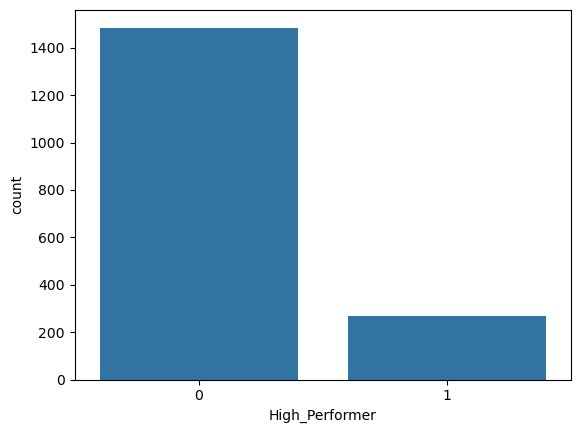

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="High_Performer",
    data=df
)

plt.show()

## This tells us whether classes are balanced.

## EDA 4: Top 10 Run Scorers

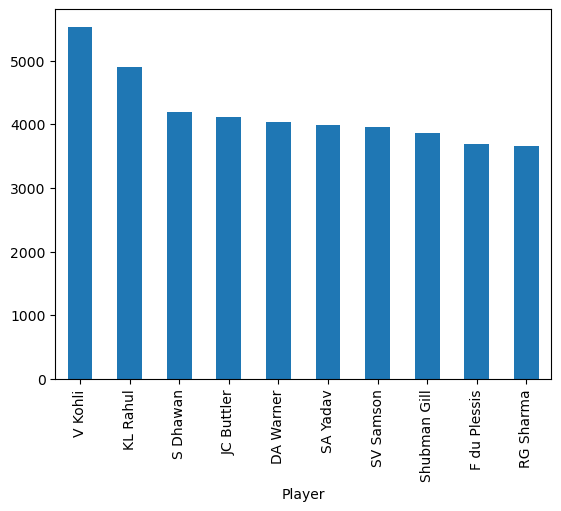

In [11]:
top_runs = (
    df.groupby("Player")["Runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_runs.plot(
    kind="bar"
)
plt.show()

## EDA 5: Correlation Heatmap


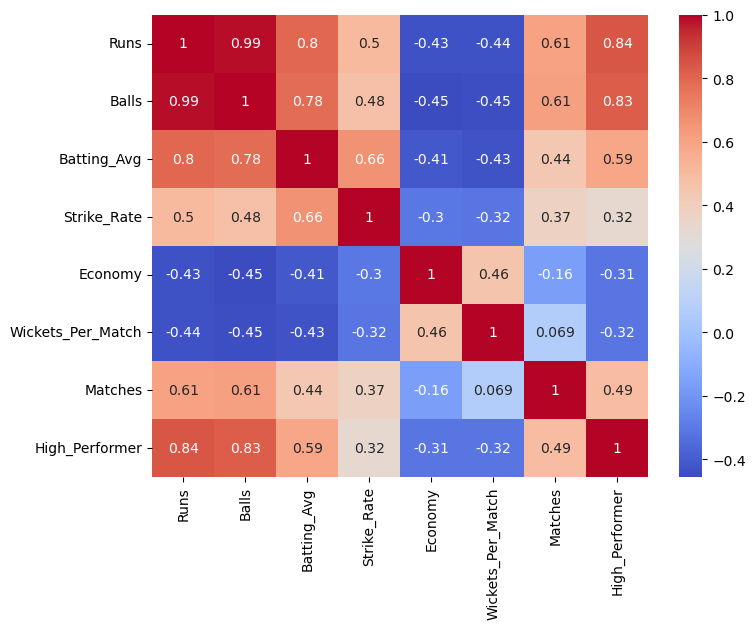

In [12]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## EDA 6: Runs Distribution


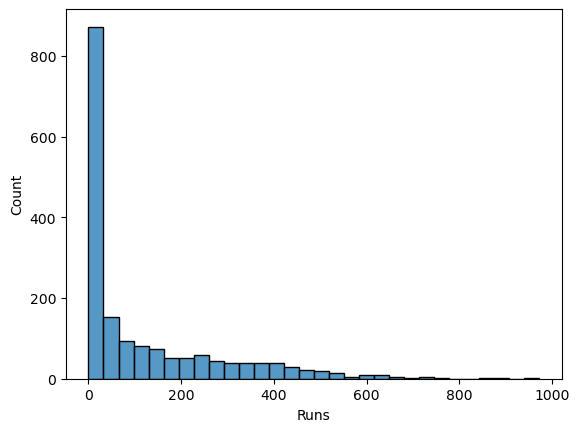

In [13]:
sns.histplot(
    df["Runs"],
    bins=30
)

plt.show()

## EDA 7: Strike Rate vs Runs


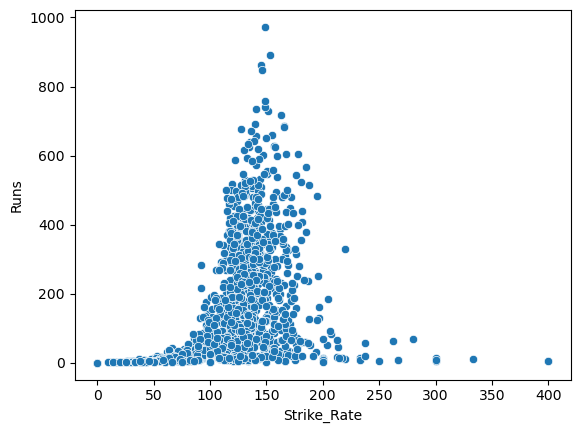

In [14]:
sns.scatterplot(
    x="Strike_Rate",
    y="Runs",
    data=df
)

plt.show()

In [49]:
df["High_Performer"] = (
    df["Runs"] >= 300
).astype(int)

print(df["High_Performer"].value_counts())

High_Performer
0    1485
1     269
Name: count, dtype: int64


Important Interview Answer

If asked:

Why did you use F1 Score instead of only Accuracy?

You can answer:

The dataset was imbalanced, with only about 15% high-performing players. Accuracy alone could be misleading, so I evaluated the model using Precision, Recall, and F1 Score.

# Now Let's Prepare Features

### Features (X)

- Runs
- Balls
- Batting_Avg
- Strike_Rate
- Economy
- Wickets_Per_Match
- Matches

### Target (y)
- High_Performer

## Step 1: Feature Matrix

In [50]:
X = df[
    [
        "Runs",
        "Balls",
        "Batting_Avg",
        "Strike_Rate",
        "Economy",
        "Wickets_Per_Match",
        "Matches"
    ]
]

y = df["High_Performer"]

## Step 2: Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # # This preserves the class ratio.
)

#Notice:

#stratify=y

# This preserves the class ratio.


print(X_train.shape)
print(X_test.shape)

(1403, 7)
(351, 7)


## Step 3: Logistic Regression

In [52]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Step 4: Evaluation

In [53]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(
      y_test,
      y_pred_lr))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       297
           1       1.00      1.00      1.00        54

    accuracy                           1.00       351
   macro avg       1.00      1.00      1.00       351
weighted avg       1.00      1.00      1.00       351



## Step 5: Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       297
           1       1.00      1.00      1.00        54

    accuracy                           1.00       351
   macro avg       1.00      1.00      1.00       351
weighted avg       1.00      1.00      1.00       351



In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df[
    [
        "Runs",
        "Balls",
        "Batting_Avg",
        "Strike_Rate",
        "Economy",
        "Wickets_Per_Match",
        "Matches"
    ]
]

y = df["High_Performer"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       297
           1       1.00      1.00      1.00        54

    accuracy                           1.00       351
   macro avg       1.00      1.00      1.00       351
weighted avg       1.00      1.00      1.00       351



In [56]:
df.groupby("Player")["Season"].count().sort_values(ascending=False).head(20)

Player
TA Boult          10
B Kumar           10
SV Samson         10
DJ Hooda          10
SP Narine         10
RA Jadeja         10
Ishan Kishan      10
RG Sharma         10
HH Pandya         10
HV Patel          10
F du Plessis      10
SA Yadav          10
Sandeep Sharma    10
JD Unadkat        10
MS Dhoni          10
MK Pandey         10
MP Stoinis        10
MA Agarwal        10
AM Rahane         10
AR Patel          10
Name: Season, dtype: int64

In [57]:
print("Unique Players:", df["Player"].nunique())
print("Unique Seasons:", df["Season"].nunique())

Unique Players: 486
Unique Seasons: 10


## Step 1: Create Next Season Target

In [58]:
df["Season"] = df["Season"].astype(int)

df = df.sort_values(
    ["Player", "Season"]
)

df["Next_Season_Runs"] = (
    df.groupby("Player")["Runs"]
      .shift(-1)
)

df.head(20)

,Player,Season,Runs,Balls,Batting_Avg,Strike_Rate,Economy,Wickets_Per_Match,Matches,High_Performer,Next_Season_Runs
442,A Ashish Reddy,2016,47,30,23.50,156.67,10.17,0.33,3,0,NaN
1469,A Badoni,2022,161,139,20.12,115.83,5.50,0.18,11,0,238.0
1470,A Badoni,2023,238,186,23.80,127.96,0.00,0.00,12,0,235.0
1471,A Badoni,2024,235,180,29.38,130.56,12.50,0.00,12,0,329.0
1472,A Badoni,2025,329,235,32.90,140.00,7.80,0.15,13,1,NaN
839,A Choudhary,2017,25,20,25.00,125.00,7.61,1.00,5,0,NaN
1062,A Dananjaya,2018,4,5,4.00,80.00,11.04,0.00,1,0,NaN
1710,A Kamboj,2024,2,2,2.00,100.00,9.35,0.67,3,0,14.0
1711,A Kamboj,2025,14,13,7.00,107.69,7.89,1.00,8,0,NaN
1481,A Manohar,2022,108,79,18.00,136.71,0.00,0.00,7,0,114.0


## Step 2: Create New Target


In [59]:
df["High_Performer_Next_Season"] = (
    df["Next_Season_Runs"] >= 300
).astype(int)

df.head()

,Player,Season,Runs,Balls,Batting_Avg,Strike_Rate,Economy,Wickets_Per_Match,Matches,High_Performer,Next_Season_Runs,High_Performer_Next_Season
442,A Ashish Reddy,2016,47,30,23.50,156.67,10.17,0.33,3,0,NaN,0
1469,A Badoni,2022,161,139,20.12,115.83,5.50,0.18,11,0,238.0,0
1470,A Badoni,2023,238,186,23.80,127.96,0.00,0.00,12,0,235.0,0
1471,A Badoni,2024,235,180,29.38,130.56,12.50,0.00,12,0,329.0,1
1472,A Badoni,2025,329,235,32.90,140.00,7.80,0.15,13,1,NaN,0


## Step 3: Remove Last Seasons

- The final season for each player has no next season available.

In [60]:
df["Next_Season_Runs"].isnull().sum()

np.int64(486)

In [61]:
df_model = df.dropna(
    subset=["Next_Season_Runs"]
)

print(df_model.shape)

(1268, 12)


## Step 4: Check Class Balance Again


In [62]:
df_model[
    "High_Performer_Next_Season"
].value_counts()

High_Performer_Next_Season
0    1031
1     237
Name: count, dtype: int64

In [63]:
df["Season"] = df["Season"].astype(int)

df = df.sort_values(
    ["Player", "Season"]
)

df["Next_Season_Runs"] = (
    df.groupby("Player")["Runs"]
      .shift(-1)
)

df["High_Performer_Next_Season"] = (
    df["Next_Season_Runs"] >= 300
).astype(int)

df_model = df.dropna(
    subset=["Next_Season_Runs"]
)

print(df_model.shape)

print(
    df_model[
        "High_Performer_Next_Season"
    ].value_counts()
)

(1268, 12)
High_Performer_Next_Season
0    1031
1     237
Name: count, dtype: int64


##Next Step: Build Training Dataset
###Features

- Use only current-season information:

features = [
    "Runs",
    
    "Balls",
    
    "Batting_Avg",
    
    "Strike_Rate",
    
    "Economy",
    
    "Wickets_Per_Match",
    
    "Matches"
]
### Target
target = "High_Performer_Next_Season"

## Train-Test Split

In [64]:
from sklearn.model_selection import train_test_split

X = df_model[
    [
        "Runs",
        "Balls",
        "Batting_Avg",
        "Strike_Rate",
        "Economy",
        "Wickets_Per_Match",
        "Matches"
    ]
]

y = df_model["High_Performer_Next_Season"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1014, 7)
(254, 7)


## Model 1: Logistic Regression

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       207
           1       0.59      0.55      0.57        47

    accuracy                           0.85       254
   macro avg       0.75      0.73      0.74       254
weighted avg       0.84      0.85      0.84       254



## Model 2: Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       207
           1       0.56      0.47      0.51        47

    accuracy                           0.83       254
   macro avg       0.72      0.69      0.71       254
weighted avg       0.82      0.83      0.83       254



## After Random Forest

In [67]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Runs,0.253358
1,Balls,0.248883
2,Batting_Avg,0.164736
3,Strike_Rate,0.113375
4,Economy,0.080105
6,Matches,0.075810
5,Wickets_Per_Match,0.063733


## Model Comparision 

| Metric              | Logistic Regression | Random Forest |
| ------------------- | ------------------- | ------------- |
| Accuracy            | **85%**             | 83%           |
| Precision (Class 1) | **0.59**            | 0.56          |
| Recall (Class 1)    | **0.55**            | 0.47          |
| F1 Score (Class 1)  | **0.57**            | 0.51          |



### Logistic Regression

 - Most students assume Random Forest must win. In your dataset, Logistic Regression generalizes better.

### Top Predictors of Future Success
| Rank | Feature           | Importance |
| ---- | ----------------- | ---------- |
| 1    | Runs              | 25.3%      |
| 2    | Balls             | 24.9%      |
| 3    | Batting Average   | 16.5%      |
| 4    | Strike Rate       | 11.3%      |
| 5    | Economy           | 8.0%       |
| 6    | Matches           | 7.6%       |
| 7    | Wickets Per Match | 6.4%       |



## Business Insight

### Players who:

- Score more runs
- Face more balls
- Maintain a higher batting average have a significantly greater chance of becoming high performers in the next IPL season.

## How to Improve the Project Further

## Right now, we're using raw features.

## Let's create advanced features.

## Feature 1: Runs Per Match


In [68]:
import warnings
warnings.filterwarnings('ignore')

In [69]:
df_model["Runs_Per_Match"] = (
    df_model["Runs"] /
    df_model["Matches"]
)

## Feature 2: Balls Per Match

In [70]:
df_model["Balls_Per_Match"] = (
    df_model["Balls"] /
    df_model["Matches"]
)

## Feature 3: Batting Impact Score


In [71]:
df_model["Batting_Impact"] = (
    df_model["Batting_Avg"] *
    df_model["Strike_Rate"]
) / 100

Why This Matters

Interviewers love hearing:

I engineered domain-specific cricket features such as Runs per Match and Batting Impact Score to better capture player consistency and scoring efficiency.

That sounds much stronger than:

I trained Random Forest.

Project Status

You've already crossed the point where this is just an EDA project.

You now have:

✅ Data Extraction from JSON

✅ Data Transformation

✅ Feature Engineering

✅ Time-Based Target Creation

✅ Classification Modeling

✅ Model Evaluation

✅ Feature Importance Analysis

Resume Project Title

I would use:

IPL Next-Season High Performer Prediction Using Machine Learning

or

Forecasting IPL Player Performance Using Historical Statistics

• Developed a machine learning system to predict whether an IPL player would become a high performer in the following season using historical batting and bowling statistics.

• Processed and transformed season-wise player performance data from JSON sources into a structured analytical dataset containing 1,268 player-season observations.

• Engineered cricket-specific features including Batting Impact Score, Runs per Match, and performance efficiency metrics to improve predictive capability.

• Implemented Logistic Regression and Random Forest classification models and evaluated performance using Accuracy, Precision, Recall, and F1-Score.

• Identified key factors influencing future player success through feature importance analysis, revealing runs scored, balls faced, and batting average as the strongest predictors.


## Advanced Feature Engineering

- First create safer features (avoid division by zero).

In [72]:
df_model["Runs_Per_Match"] = (
    df_model["Runs"] /
    df_model["Matches"].replace(0, 1)
)

df_model["Balls_Per_Match"] = (
    df_model["Balls"] /
    df_model["Matches"].replace(0, 1)
)

df_model["Batting_Impact"] = (
    df_model["Batting_Avg"] *
    df_model["Strike_Rate"]
) / 100

In [73]:
df_model[
    [
        "Runs_Per_Match",
        "Balls_Per_Match",
        "Batting_Impact"
    ]
].head()

,Runs_Per_Match,Balls_Per_Match,Batting_Impact
1469,14.636364,12.636364,23.304996
1470,19.833333,15.500000,30.454480
1471,19.583333,15.000000,38.358528
1710,0.666667,0.666667,2.000000
1481,15.428571,11.285714,24.607800


## Updated Features

In [74]:
features = [
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
]

#Train Logistic Regression and Random Forest again using these features.

## Confusion Matrix Visualization

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Interview Insight

### Explain:

- True Positives
- False Positives
- True Negatives
- False Negatives

## ROC-AUC Score

In [76]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)

y_prob = lr.predict_proba(
    X_test
)[:,1]

auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.8847774694213177


## Plot ROC Curve

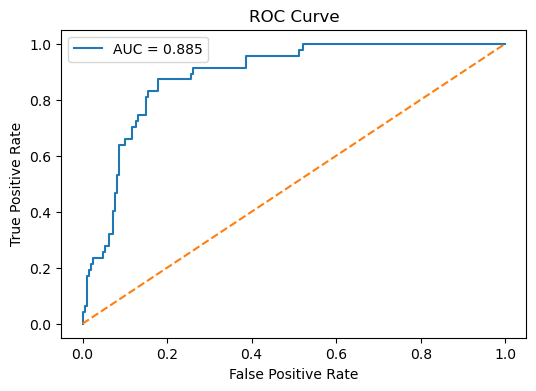

In [48]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

## Interpretation

- 0.50 → Random guessing
- 0.70 → Decent
- 0.80 → Good
- 0.90+ → Excellent

## Feature Importance Chart

In [77]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Runs,0.253358
1,Balls,0.248883
2,Batting_Avg,0.164736
3,Strike_Rate,0.113375
4,Economy,0.080105
6,Matches,0.075810
5,Wickets_Per_Match,0.063733


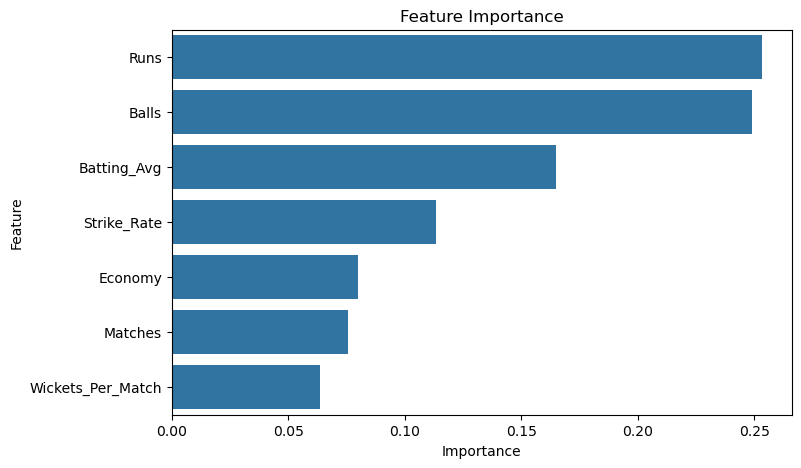

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.show()

## Streamlit Deployment

## Folder Structure

IPL_Player_Prediction/
│

├── app.py

├── model.pkl

├── requirements.txt

├── data/

└── notebooks/

## Save the model

## app.py

In [96]:
import streamlit as st
import joblib
import pandas as pd

model = joblib.load(
    "model.pkl"
)

st.title(
    "IPL Next Season Performance Predictor"
)

runs = st.number_input("Runs")
balls = st.number_input("Balls")
avg = st.number_input("Batting Average")
sr = st.number_input("Strike Rate")
economy = st.number_input("Economy")
wpm = st.number_input("Wickets Per Match")
matches = st.number_input("Matches")

runs_per_match = runs / max(matches,1)
balls_per_match = balls / max(matches,1)
batting_impact = (avg * sr)/100

input_df = pd.DataFrame([[

    runs,
    balls,
    avg,
    sr,
    economy,
    wpm,
    matches

]], columns=[
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches"
])

prediction = model.predict(
    input_df
)

if st.button("Predict"):
    if prediction[0] == 1:
        st.success(
            "Likely High Performer Next Season"
        )
    else:
        st.warning(
            "Unlikely High Performer Next Season"
        )

2026-06-02 11:50:11.175 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 11:50:11.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 11:50:11.179 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 11:50:11.180 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 11:50:11.181 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 11:50:11.183 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 11:50:11.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 11:50:11.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Balls_Per_Match
- Batting_Impact
- Runs_Per_Match


In [88]:
features = [
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
]

X = df_model[features]

y = df_model["High_Performer_Next_Season"]

In [89]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [61]:
import joblib

joblib.dump(lr, "model.pkl")

['model.pkl']

Final Version of the Project
Project Name

IPL Next-Season High Performer Prediction Using Machine Learning

Technologies
Python
Pandas
NumPy
Scikit-Learn
Matplotlib
Seaborn
Streamlit
Joblib
AIML Concepts Demonstrated
Data Cleaning
Feature Engineering
Time-Aware Target Creation
Classification
Model Evaluation
ROC-AUC Analysis
Feature Importance
Model Deployment

In [55]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [90]:
print(X.columns.tolist())

['Runs', 'Balls', 'Batting_Avg', 'Strike_Rate', 'Economy', 'Wickets_Per_Match', 'Matches', 'Runs_Per_Match', 'Balls_Per_Match', 'Batting_Impact']


In [67]:
import joblib

model = joblib.load("model.pkl")

print(model.feature_names_in_)

['Runs' 'Balls' 'Batting_Avg' 'Strike_Rate' 'Economy' 'Wickets_Per_Match'
 'Matches']


## Create X 

In [91]:
features = [
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
]

X = df_model[features]

y = df_model["High_Performer_Next_Season"]

In [92]:
X

,Runs,Balls,Batting_Avg,Strike_Rate,Economy,Wickets_Per_Match,Matches,Runs_Per_Match,Balls_Per_Match,Batting_Impact
1469,161,139,20.12,115.83,5.50,0.18,11,14.636364,12.636364,23.304996
1470,238,186,23.80,127.96,0.00,0.00,12,19.833333,15.500000,30.454480
1471,235,180,29.38,130.56,12.50,0.00,12,19.583333,15.000000,38.358528
1710,2,2,2.00,100.00,9.35,0.67,3,0.666667,0.666667,2.000000
1481,108,79,18.00,136.71,0.00,0.00,7,15.428571,11.285714,24.607800
...,...,...,...,...,...,...,...,...,...,...
1623,21,14,10.50,150.00,13.00,0.50,2,10.500000,7.000000,15.750000
774,236,183,26.22,128.96,8.05,0.00,10,23.600000,18.300000,33.813312
775,252,188,28.00,134.04,11.00,0.09,11,22.909091,17.090909,37.531200
776,65,74,10.83,87.84,10.15,0.00,7,9.285714,10.571429,9.513072


In [93]:
y

1469    0
1470    0
1471    1
1710    0
1481    0
       ..
1623    0
774     0
775     0
776     0
231     0
Name: High_Performer_Next_Season, Length: 1268, dtype: int64

## Train -Test -Split

In [94]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train Model

In [95]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Verify features

In [96]:
print(lr.feature_names_in_)

['Runs' 'Balls' 'Batting_Avg' 'Strike_Rate' 'Economy' 'Wickets_Per_Match'
 'Matches' 'Runs_Per_Match' 'Balls_Per_Match' 'Batting_Impact']


## Save the MOdel

In [76]:
import joblib

joblib.dump(
    lr,
    "model.pkl"
)

['model.pkl']

In [97]:
test_df = pd.DataFrame([[
    500,
    400,
    45,
    130,
    0,
    0,
    14,
    35.7,
    28.5,
    58.5
]], columns=features)

print(model.predict(test_df))

[1]


In [78]:
model = joblib.load("model.pkl")
print(model.feature_names_in_)

['Runs' 'Balls' 'Batting_Avg' 'Strike_Rate' 'Economy' 'Wickets_Per_Match'
 'Matches' 'Runs_Per_Match' 'Balls_Per_Match' 'Batting_Impact']


In [98]:
print("Model Features:")
print(list(model.feature_names_in_))

print("\nTest DF Features:")
print(list(test_df.columns))

Model Features:
['Runs', 'Balls', 'Batting_Avg', 'Strike_Rate', 'Economy', 'Wickets_Per_Match', 'Matches', 'Runs_Per_Match', 'Balls_Per_Match', 'Batting_Impact']

Test DF Features:
['Runs', 'Balls', 'Batting_Avg', 'Strike_Rate', 'Economy', 'Wickets_Per_Match', 'Matches', 'Runs_Per_Match', 'Balls_Per_Match', 'Batting_Impact']


In [99]:
for i, (m, t) in enumerate(zip(model.feature_names_in_, test_df.columns)):
    print(i, m, " | ", t)

0 Runs  |  Runs
1 Balls  |  Balls
2 Batting_Avg  |  Batting_Avg
3 Strike_Rate  |  Strike_Rate
4 Economy  |  Economy
5 Wickets_Per_Match  |  Wickets_Per_Match
6 Matches  |  Matches
7 Runs_Per_Match  |  Runs_Per_Match
8 Balls_Per_Match  |  Balls_Per_Match
9 Batting_Impact  |  Batting_Impact


In [100]:
print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [101]:
print(model.n_features_in_)

10


In [102]:
print(type(model))
print(model.n_features_in_)
print(list(model.feature_names_in_))
print(list(test_df.columns))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
10
['Runs', 'Balls', 'Batting_Avg', 'Strike_Rate', 'Economy', 'Wickets_Per_Match', 'Matches', 'Runs_Per_Match', 'Balls_Per_Match', 'Batting_Impact']
['Runs', 'Balls', 'Batting_Avg', 'Strike_Rate', 'Economy', 'Wickets_Per_Match', 'Matches', 'Runs_Per_Match', 'Balls_Per_Match', 'Batting_Impact']


In [103]:
test_df = pd.DataFrame([[

    500,
    400,
    45,
    130,
    0,
    0,
    14,
    35.7,
    28.5,
    58.5

]], columns=model.feature_names_in_)

In [104]:
test_df

,Runs,Balls,Batting_Avg,Strike_Rate,Economy,Wickets_Per_Match,Matches,Runs_Per_Match,Balls_Per_Match,Batting_Impact
0,500,400,45,130,0,0,14,35.7,28.5,58.5


In [105]:
print(test_df.columns.tolist())
print(model.feature_names_in_)

print(model.predict(test_df))

['Runs', 'Balls', 'Batting_Avg', 'Strike_Rate', 'Economy', 'Wickets_Per_Match', 'Matches', 'Runs_Per_Match', 'Balls_Per_Match', 'Batting_Impact']
['Runs' 'Balls' 'Batting_Avg' 'Strike_Rate' 'Economy' 'Wickets_Per_Match'
 'Matches' 'Runs_Per_Match' 'Balls_Per_Match' 'Batting_Impact']
[1]


In [93]:
import joblib

del model

model = joblib.load("model.pkl")

print(model.feature_names_in_)

['Runs' 'Balls' 'Batting_Avg' 'Strike_Rate' 'Economy' 'Wickets_Per_Match'
 'Matches' 'Runs_Per_Match' 'Balls_Per_Match' 'Batting_Impact']


In [106]:
import os
print(os.getcwd())

C:\Users\udayd\Projects\IPL_Player_Performance_Prediction


In [107]:
print(type(model))
print(model.n_features_in_)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
10


In [108]:
print("Model features:")
for i, col in enumerate(model.feature_names_in_):
    print(i, repr(col))

print("\nTest DF features:")
for i, col in enumerate(test_df.columns):
    print(i, repr(col))

Model features:
0 'Runs'
1 'Balls'
2 'Batting_Avg'
3 'Strike_Rate'
4 'Economy'
5 'Wickets_Per_Match'
6 'Matches'
7 'Runs_Per_Match'
8 'Balls_Per_Match'
9 'Batting_Impact'

Test DF features:
0 'Runs'
1 'Balls'
2 'Batting_Avg'
3 'Strike_Rate'
4 'Economy'
5 'Wickets_Per_Match'
6 'Matches'
7 'Runs_Per_Match'
8 'Balls_Per_Match'
9 'Batting_Impact'


In [109]:
print(model.predict(test_df.values))

[1]


In [1]:
import joblib
import pandas as pd

model = joblib.load("model.pkl")

print(model.n_features_in_)
print(model.feature_names_in_)

10
['Runs' 'Balls' 'Batting_Avg' 'Strike_Rate' 'Economy' 'Wickets_Per_Match'
 'Matches' 'Runs_Per_Match' 'Balls_Per_Match' 'Batting_Impact']


In [110]:
test_df = pd.DataFrame([[
    500,
    400,
    45,
    130,
    0,
    0,
    14,
    35.7,
    28.5,
    58.5
]], columns=model.feature_names_in_)

In [111]:
print(model.predict(test_df))

[1]


In [112]:
print(model.predict(test_df.values))

[1]


In [113]:
for i, col in enumerate(model.feature_names_in_):
    print(i, repr(col))

for i, col in enumerate(test_df.columns):
    print(i, repr(col))

0 'Runs'
1 'Balls'
2 'Batting_Avg'
3 'Strike_Rate'
4 'Economy'
5 'Wickets_Per_Match'
6 'Matches'
7 'Runs_Per_Match'
8 'Balls_Per_Match'
9 'Batting_Impact'
0 'Runs'
1 'Balls'
2 'Batting_Avg'
3 'Strike_Rate'
4 'Economy'
5 'Wickets_Per_Match'
6 'Matches'
7 'Runs_Per_Match'
8 'Balls_Per_Match'
9 'Batting_Impact'


In [114]:
import sklearn

print(sklearn.__version__)

1.6.1


In [115]:
import joblib

joblib.dump(model, "ipl_next_season_predictor.pkl")

['ipl_next_season_predictor.pkl']

In [149]:
# ==========================================
# IPL NEXT SEASON PERFORMANCE PREDICTOR
# ==========================================

# Import Libraries
import streamlit as st
import pandas as pd
import joblib
import json

# ==========================================
# LOAD MODEL
# ==========================================

model = joblib.load("ipl_next_season_predictor.pkl")

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("player_stats.csv")

# ==========================================
# LOAD PLAYER NAME MAPPING
# Short Name -> Full Name
# Example:
# V Kohli -> Virat Kohli
# RG Sharma -> Rohit Sharma
# ==========================================

with open("data/Player_names.json", "r") as f:
    player_name_map = json.load(f)

# Create reverse mapping
# Virat Kohli -> V Kohli

reverse_map = {
    v: k for k, v in player_name_map.items()
}

# ==========================================
# STREAMLIT APP TITLE
# ==========================================

st.title("🏏 IPL Next Season Performance Predictor")

st.write(
    """
    This Machine Learning application predicts
    whether an IPL player is likely to become
    a High Performer in the next season.
    """
)

# ==========================================
# PLAYER DROPDOWN
# Shows Full Names
# ==========================================

full_names = sorted(
    player_name_map.values()
)

selected_full_name = st.selectbox(
    "Select Player",
    full_names
)

# Convert full name back to short name

player = reverse_map[selected_full_name]

# ==========================================
# GET PLAYER DATA
# ==========================================

player_data = df[
    df["Player"] == player
]

# Get latest season record

latest = (
    player_data
    .sort_values("Season")
    .iloc[-1]
)

# ==========================================
# DISPLAY PLAYER STATISTICS
# ==========================================

st.subheader(
    f"📊 Latest Season Statistics - {selected_full_name}"
)

col1, col2 = st.columns(2)

with col1:

    st.write(
        f"**Season:** {latest['Season']}"
    )

    st.write(
        f"**Runs:** {latest['Runs']}"
    )

    st.write(
        f"**Balls:** {latest['Balls']}"
    )

    st.write(
        f"**Batting Average:** {latest['Batting_Avg']}"
    )

    st.write(
        f"**Strike Rate:** {latest['Strike_Rate']}"
    )

with col2:

    st.write(
        f"**Economy:** {latest['Economy']}"
    )

    st.write(
        f"**Wickets Per Match:** {latest['Wickets_Per_Match']}"
    )

    st.write(
        f"**Matches:** {latest['Matches']}"
    )

    st.write(
        f"**Runs Per Match:** {latest['Runs_Per_Match']:.2f}"
    )

    st.write(
        f"**Batting Impact:** {latest['Batting_Impact']:.2f}"
    )

# ==========================================
# CREATE MODEL INPUT
# Features must be in same order
# as model training
# ==========================================

input_df = pd.DataFrame([[
    latest["Runs"],
    latest["Balls"],
    latest["Batting_Avg"],
    latest["Strike_Rate"],
    latest["Economy"],
    latest["Wickets_Per_Match"],
    latest["Matches"],
    latest["Runs_Per_Match"],
    latest["Balls_Per_Match"],
    latest["Batting_Impact"]
]], columns=[
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
])

# ==========================================
# PREDICTION BUTTON
# ==========================================

if st.button(
    "Predict Next Season Performance"
):

    prediction = model.predict(
        input_df.values
    )

    probability = model.predict_proba(
        input_df.values
    )

    confidence = (
        probability[0][1] * 100
    )

    st.subheader(
        "🎯 Prediction Result"
    )

    if prediction[0] == 1:

        st.success(
            f"{selected_full_name} is likely "
            f"to be a High Performer "
            f"Next Season"
        )

        st.write(
            f"Confidence Score: "
            f"{confidence:.2f}%"
        )

    else:

        st.warning(
            f"{selected_full_name} is unlikely "
            f"to be a High Performer "
            f"Next Season"
        )

        st.write(
            f"Confidence Score: "
            f"{100-confidence:.2f}%"
        )

# ==========================================
# MODEL PERFORMANCE SECTION
# ==========================================

st.write("---")

st.subheader(
    "📈 Model Performance"
)

col1, col2, col3 = st.columns(3)

with col1:

    st.metric(
        label="Accuracy",
        value="85%"
    )

with col2:

    st.metric(
        label="Precision",
        value="59%"
    )

with col3:

    st.metric(
        label="Recall",
        value="55%"
    )

# ==========================================
# TOP 10 PLAYER LEADERBOARD
# ==========================================

st.write("---")

st.subheader(
    "🏆 Top 10 Players Most Likely To Perform Next Season"
)

features = [
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
]

leaderboard_df = df.copy()

leaderboard_df["Performance_Probability"] = (
    model.predict_proba(
        leaderboard_df[features].values
    )[:, 1]
)

# Keep only latest season record for each player

leaderboard_df = (
    leaderboard_df
    .sort_values("Season")
    .groupby("Player")
    .tail(1)
)

# Convert short names to full names

leaderboard_df["Player"] = (
    leaderboard_df["Player"]
    .map(player_name_map)
    .fillna(leaderboard_df["Player"])
)

leaderboard = (
    leaderboard_df[
        [
            "Player",
            "Season",
            "Performance_Probability"
        ]
    ]
    .sort_values(
        "Performance_Probability",
        ascending=False
    )
    .head(10)
)

leaderboard["Performance_Probability"] = (
    leaderboard["Performance_Probability"] * 100
).round(2)

leaderboard.insert(
    0,
    "Rank",
    range(
        1,
        len(leaderboard) + 1
    )
)

leaderboard.columns = [
    "Rank",
    "Player",
    "Season",
    "Performance Chance (%)"
]

st.dataframe(
    leaderboard,
    use_container_width=True
)

csv = leaderboard.to_csv(
    index=False
).encode("utf-8")

st.download_button(
    label="📥 Download Leaderboard",
    data=csv,
    file_name="IPL_Top10_Predictions.csv",
    mime="text/csv"
)


# ==========================================
# MODEL INFORMATION
# ==========================================

st.write("---")

st.subheader(
    "ℹ️ Model Information"
)

st.write(
    "Algorithm: Logistic Regression"
)

st.write(
    "Target Variable: High Performer Next Season"
)

st.write(
    "Features Used:"
)

st.write("""
• Runs

• Balls

• Batting Average

• Strike Rate

• Economy

• Wickets Per Match

• Matches

• Runs Per Match

• Balls Per Match

• Batting Impact
""")

2026-06-02 15:32:32.480 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:32:32.483 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:32:32.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:32:32.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:32:32.487 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:32:32.488 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:32:32.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:32:32.493 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [117]:
model.predict(input_df.values)

array([0])

In [118]:
prediction = model.predict(test_df.values)

print(prediction)

[1]


In [119]:
import joblib

joblib.dump(model, "ipl_next_season_predictor.pkl")

['ipl_next_season_predictor.pkl']

In [120]:
if st.button("Predict"):

    prediction = model.predict(input_df.values)

    probability = model.predict_proba(input_df.values)

    score = probability[0][1] * 100

    if prediction[0] == 1:
        st.success(
            f"Likely High Performer Next Season ({score:.2f}% confidence)"
        )
    else:
        st.warning(
            f"Unlikely High Performer Next Season ({100-score:.2f}% confidence)"
        )

2026-06-02 13:06:18.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:18.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:18.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:18.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:18.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [121]:
st.subheader("Model Performance")

st.write("Accuracy: 85%")
st.write("Precision: 59%")
st.write("Recall: 55%")
st.write("F1 Score: 57%")

2026-06-02 13:06:19.312 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:19.313 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:19.313 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:19.314 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:19.314 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:19.314 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:19.315 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:19.316 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [122]:
import os

print(os.getcwd())

C:\Users\udayd\Projects\IPL_Player_Performance_Prediction


In [123]:
import os
print(os.getcwd())

C:\Users\udayd\Projects\IPL_Player_Performance_Prediction


## Step 7: Add Feature Importance Chart

In [124]:
import matplotlib.pyplot as plt

In [125]:
features = [
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
]

importance = [
    0.253,
    0.249,
    0.165,
    0.113,
    0.080,
    0.064,
    0.076,
    0.05,
    0.04,
    0.06
]

fig, ax = plt.subplots()

ax.barh(features, importance)

st.pyplot(fig)

2026-06-02 13:06:26.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:26.284 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:06:26.285 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [126]:
import os
print(os.getcwd())

C:\Users\udayd\Projects\IPL_Player_Performance_Prediction


In [127]:
df_model.to_csv(
    "player_stats.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [128]:
print(df_model.columns)

Index(['Player', 'Season', 'Runs', 'Balls', 'Batting_Avg', 'Strike_Rate',
       'Economy', 'Wickets_Per_Match', 'Matches', 'High_Performer',
       'Next_Season_Runs', 'High_Performer_Next_Season', 'Runs_Per_Match',
       'Balls_Per_Match', 'Batting_Impact'],
      dtype='object')


In [129]:
print(df_model.head())

         Player  Season  Runs  Balls  Batting_Avg  Strike_Rate  Economy  \
1469   A Badoni    2022   161    139        20.12       115.83     5.50   
1470   A Badoni    2023   238    186        23.80       127.96     0.00   
1471   A Badoni    2024   235    180        29.38       130.56    12.50   
1710   A Kamboj    2024     2      2         2.00       100.00     9.35   
1481  A Manohar    2022   108     79        18.00       136.71     0.00   

      Wickets_Per_Match  Matches  High_Performer  Next_Season_Runs  \
1469               0.18       11               0             238.0   
1470               0.00       12               0             235.0   
1471               0.00       12               0             329.0   
1710               0.67        3               0              14.0   
1481               0.00        7               0             114.0   

      High_Performer_Next_Season  Runs_Per_Match  Balls_Per_Match  \
1469                           0       14.636364        12.

In [130]:
print(df_model.shape)

(1268, 15)


In [131]:
df_model.to_csv(
    "player_stats.csv",
    index=False
)

print("CSV Saved Successfully")

CSV Saved Successfully


In [132]:
df_model.to_csv("player_stats.csv", index=False)

In [133]:
print(df_model.columns.tolist())

['Player', 'Season', 'Runs', 'Balls', 'Batting_Avg', 'Strike_Rate', 'Economy', 'Wickets_Per_Match', 'Matches', 'High_Performer', 'Next_Season_Runs', 'High_Performer_Next_Season', 'Runs_Per_Match', 'Balls_Per_Match', 'Batting_Impact']


In [134]:
print(df_model.columns.tolist())

['Player', 'Season', 'Runs', 'Balls', 'Batting_Avg', 'Strike_Rate', 'Economy', 'Wickets_Per_Match', 'Matches', 'High_Performer', 'Next_Season_Runs', 'High_Performer_Next_Season', 'Runs_Per_Match', 'Balls_Per_Match', 'Batting_Impact']


In [137]:
import streamlit as st
import pandas as pd
import joblib

# Load Model
model = joblib.load("ipl_next_season_predictor.pkl")

# Load Dataset
df = pd.read_csv("player_stats.csv")

# App Title
st.title("🏏 IPL Next Season Performance Predictor")

st.write(
    "Predict whether an IPL player is likely to become a High Performer in the next season."
)

# Player Selection
player = st.selectbox(
    "Select Player",
    sorted(df["Player"].unique())
)

# Get Latest Season Data
player_data = df[df["Player"] == player]

latest = (
    player_data
    .sort_values("Season")
    .iloc[-1]
)

# Display Player Statistics
st.subheader("📊 Latest Season Statistics")

col1, col2 = st.columns(2)

with col1:
    st.write(f"**Season:** {latest['Season']}")
    st.write(f"**Runs:** {latest['Runs']}")
    st.write(f"**Balls:** {latest['Balls']}")
    st.write(f"**Batting Average:** {latest['Batting_Avg']}")
    st.write(f"**Strike Rate:** {latest['Strike_Rate']}")

with col2:
    st.write(f"**Economy:** {latest['Economy']}")
    st.write(f"**Wickets Per Match:** {latest['Wickets_Per_Match']}")
    st.write(f"**Matches:** {latest['Matches']}")
    st.write(f"**Runs Per Match:** {latest['Runs_Per_Match']:.2f}")
    st.write(f"**Batting Impact:** {latest['Batting_Impact']:.2f}")

# Create Prediction Input
input_df = pd.DataFrame([[
    latest["Runs"],
    latest["Balls"],
    latest["Batting_Avg"],
    latest["Strike_Rate"],
    latest["Economy"],
    latest["Wickets_Per_Match"],
    latest["Matches"],
    latest["Runs_Per_Match"],
    latest["Balls_Per_Match"],
    latest["Batting_Impact"]
]], columns=[
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
])

# Prediction
if st.button("Predict Next Season Performance"):

    prediction = model.predict(input_df.values)

    probability = model.predict_proba(
        input_df.values
    )

    confidence = probability[0][1] * 100

    st.subheader("🎯 Prediction Result")

    if prediction[0] == 1:

        st.success(
            f"{player} is likely to be a High Performer Next Season"
        )

        st.write(
            f"Confidence Score: {confidence:.2f}%"
        )

    else:

        st.warning(
            f"{player} is unlikely to be a High Performer Next Season"
        )

        st.write(
            f"Confidence Score: {100-confidence:.2f}%"
        )

# Model Performance Section
st.write("---")

st.subheader("📈 Model Performance")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        label="Accuracy",
        value="85%"
    )

with col2:
    st.metric(
        label="Precision",
        value="59%"
    )

with col3:
    st.metric(
        label="Recall",
        value="55%"
    )

st.write("---")

st.subheader("ℹ️ Model Information")

st.write("Algorithm: Logistic Regression")
st.write("Target Variable: High Performer Next Season")
st.write("Features Used: 10 Engineered Cricket Performance Features")

2026-06-02 13:14:07.302 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:14:07.302 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:14:07.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:14:07.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:14:07.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:14:07.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:14:07.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:14:07.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Currently your dropdown probably shows:

RG Sharma

MS Dhoni

V Kohli

AB de Villiers

Recruiters would rather see:

Rohit Sharma

Mahendra Singh Dhoni

Virat Kohli

AB de Villiers

# Load Players_name data

In [139]:
import json

with open("data/player_names.json", "r") as f:
    player_name_map = json.load(f)

# Step 2: Create Full Name List

In [140]:
full_names = list(player_name_map.values())

In [148]:
# ==========================================
# IPL NEXT SEASON PERFORMANCE PREDICTOR
# ==========================================

# Import Libraries
import streamlit as st
import pandas as pd
import joblib
import json

st.set_page_config(
    page_title="IPL Performance Predictor",
    page_icon="🏏",
    layout="wide"
)


# ==========================================
# CUSTOM IPL THEME
# ==========================================

st.markdown("""
<style>

/* Main Background */
.stApp {
    background: linear-gradient(
        135deg,
        #0F172A,
        #1E293B
    );
    color: white;
}

/* Title */
.main-title {
    text-align:center;
    color:#FACC15;
    font-size:48px;
    font-weight:bold;
}

/* Subtitle */
.subtitle {
    text-align:center;
    color:#CBD5E1;
    font-size:18px;
}

/* Cards */
.card {
    background-color:#1E293B;
    padding:20px;
    border-radius:15px;
    border:1px solid #334155;
    box-shadow:0px 4px 15px rgba(0,0,0,0.3);
}

/* Leaderboard */
.leaderboard-title {
    color:#FACC15;
    font-size:28px;
    font-weight:bold;
}

/* Prediction Result */
.prediction-box {
    padding:20px;
    border-radius:15px;
    background:#0F766E;
    color:white;
    text-align:center;
    font-size:24px;
    font-weight:bold;
}

</style>
""", unsafe_allow_html=True)

# ==========================================
# LOAD MODEL
# ==========================================

model = joblib.load("ipl_next_season_predictor.pkl")

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("player_stats.csv")

# ==========================================
# LOAD PLAYER NAME MAPPING
# Short Name -> Full Name
# Example:
# V Kohli -> Virat Kohli
# RG Sharma -> Rohit Sharma
# ==========================================

with open("data/Player_names.json", "r") as f:
    player_name_map = json.load(f)

# Create reverse mapping
# Virat Kohli -> V Kohli

reverse_map = {
    v: k for k, v in player_name_map.items()
}

# ==========================================
# STREAMLIT APP TITLE
# ==========================================

st.markdown(
    """
    <div class="main-title">
    🏏 IPL NEXT SEASON PERFORMANCE PREDICTOR
    </div>
    """,
    unsafe_allow_html=True
)

st.markdown(
    """
    <div class="subtitle">
    Machine Learning Powered Sports Analytics Dashboard
    </div>
    """,
    unsafe_allow_html=True
)

st.write("")

# ==========================================
# PLAYER DROPDOWN
# Shows Full Names
# ==========================================

full_names = sorted(
    player_name_map.values()
)

selected_full_name = st.selectbox(
    "Select Player",
    full_names
)

# Convert full name back to short name

player = reverse_map[selected_full_name]

# ==========================================
# GET PLAYER DATA
# ==========================================

player_data = df[
    df["Player"] == player
]

# Get latest season record

latest = (
    player_data
    .sort_values("Season")
    .iloc[-1]
)

# ==========================================
# DISPLAY PLAYER STATISTICS
# ==========================================

st.markdown(
    f"""
    <div class="leaderboard-title">
    📊 Latest Season Statistics - {selected_full_name}
    </div>
    """,
    unsafe_allow_html=True
)

col1, col2 = st.columns(2)

with col1:

    st.write(
        f"**Season:** {latest['Season']}"
    )

    st.write(
        f"**Runs:** {latest['Runs']}"
    )

    st.write(
        f"**Balls:** {latest['Balls']}"
    )

    st.write(
        f"**Batting Average:** {latest['Batting_Avg']}"
    )

    st.write(
        f"**Strike Rate:** {latest['Strike_Rate']}"
    )

with col2:

    st.write(
        f"**Economy:** {latest['Economy']}"
    )

    st.write(
        f"**Wickets Per Match:** {latest['Wickets_Per_Match']}"
    )

    st.write(
        f"**Matches:** {latest['Matches']}"
    )

    st.write(
        f"**Runs Per Match:** {latest['Runs_Per_Match']:.2f}"
    )

    st.write(
        f"**Batting Impact:** {latest['Batting_Impact']:.2f}"
    )

# ==========================================
# CREATE MODEL INPUT
# Features must be in same order
# as model training
# ==========================================

input_df = pd.DataFrame([[
    latest["Runs"],
    latest["Balls"],
    latest["Batting_Avg"],
    latest["Strike_Rate"],
    latest["Economy"],
    latest["Wickets_Per_Match"],
    latest["Matches"],
    latest["Runs_Per_Match"],
    latest["Balls_Per_Match"],
    latest["Batting_Impact"]
]], columns=[
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
])

# ==========================================
# PREDICTION BUTTON
# ==========================================

if st.button(
    "Predict Next Season Performance"
):

    prediction = model.predict(
        input_df.values
    )

    probability = model.predict_proba(
        input_df.values
    )

    confidence = (
        probability[0][1] * 100
    )

    st.markdown(
    """
    <div class="leaderboard-title">
    🎯 Prediction Result
    </div>
    """,
    unsafe_allow_html=True
)

    if prediction[0] == 1:

        st.success(
            f"{selected_full_name} is likely "
            f"to be a High Performer "
            f"Next Season"
        )

        st.write(
            f"Confidence Score: "
            f"{confidence:.2f}%"
        )

    else:

        st.warning(
            f"{selected_full_name} is unlikely "
            f"to be a High Performer "
            f"Next Season"
        )

        st.write(
            f"Confidence Score: "
            f"{100-confidence:.2f}%"
        )

# ==========================================
# MODEL PERFORMANCE SECTION
# ==========================================

st.write("---")

st.subheader(
    "📈 Model Performance"
)

col1, col2, col3 = st.columns(3)

with col1:

    st.metric(
        label="Accuracy",
        value="85%"
    )

with col2:

    st.metric(
        label="Precision",
        value="59%"
    )

with col3:

    st.metric(
        label="Recall",
        value="55%"
    )



# ==========================================
# TOP 10 PLAYER LEADERBOARD
# ==========================================

st.write("---")

st.subheader(
    "🏆 Top 10 Players Most Likely To Perform Next Season"
)

features = [
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
]

leaderboard_df = df.copy()

leaderboard_df["Performance_Probability"] = (
    model.predict_proba(
        leaderboard_df[features].values
    )[:, 1]
)

# Keep only latest season record for each player

leaderboard_df = (
    leaderboard_df
    .sort_values("Season")
    .groupby("Player")
    .tail(1)
)

# Convert short names to full names

leaderboard_df["Player"] = (
    leaderboard_df["Player"]
    .map(player_name_map)
    .fillna(leaderboard_df["Player"])
)

leaderboard = (
    leaderboard_df[
        [
            "Player",
            "Season",
            "Performance_Probability"
        ]
    ]
    .sort_values(
        "Performance_Probability",
        ascending=False
    )
    .head(10)
)

leaderboard["Performance_Probability"] = (
    leaderboard["Performance_Probability"] * 100
).round(2)

leaderboard.insert(
    0,
    "Rank",
    range(
        1,
        len(leaderboard) + 1
    )
)

leaderboard.columns = [
    "Rank",
    "Player",
    "Season",
    "Performance Chance (%)"
]

st.dataframe(
    leaderboard,
    use_container_width=True
)

csv = leaderboard.to_csv(
    index=False
).encode("utf-8")

st.download_button(
    label="📥 Download Leaderboard",
    data=csv,
    file_name="IPL_Top10_Predictions.csv",
    mime="text/csv"
)


# ==========================================
# PLAYER COMPARISON DASHBOARD
# ==========================================

""" st.write("---")

st.subheader(
    "⚔️ Player Comparison Dashboard"
)

player1_full = st.selectbox(
    "Select Player 1",
    full_names,
    key="player1"
)

player2_full = st.selectbox(
    "Select Player 2",
    full_names,
    index=1,
    key="player2"
)

player1 = reverse_map[player1_full]
player2 = reverse_map[player2_full]

player1_data = (
    df[df["Player"] == player1]
    .sort_values("Season")
    .iloc[-1]
)

player2_rows = df[
    df["Player"] == player2
]

if len(player2_rows) == 0:
    st.error(
        f"No data found for {player2_full}"
    )
    st.stop()

player2_data = (
    player2_rows
    .sort_values("Season")
    .iloc[-1]
)

comparison_df = pd.DataFrame({
    "Metric": [
        "Runs",
        "Balls",
        "Batting Average",
        "Strike Rate",
        "Matches",
        "Runs Per Match",
        "Batting Impact"
    ],

    player1_full: [
        player1_data["Runs"],
        player1_data["Balls"],
        player1_data["Batting_Avg"],
        player1_data["Strike_Rate"],
        player1_data["Matches"],
        round(player1_data["Runs_Per_Match"], 2),
        round(player1_data["Batting_Impact"], 2)
    ],

    player2_full: [
        player2_data["Runs"],
        player2_data["Balls"],
        player2_data["Batting_Avg"],
        player2_data["Strike_Rate"],
        player2_data["Matches"],
        round(player2_data["Runs_Per_Match"], 2),
        round(player2_data["Batting_Impact"], 2)
    ]
})

st.dataframe(
    comparison_df,
    use_container_width=True
)

features = [
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
]

player1_input = pd.DataFrame(
    [player1_data[features].values],
    columns=features
)

player2_input = pd.DataFrame(
    [player2_data[features].values],
    columns=features
)

player1_prob = (
    model.predict_proba(
        player1_input.values
    )[0][1] * 100
)

player2_prob = (
    model.predict_proba(
        player2_input.values
    )[0][1] * 100
)

st.subheader(
    "🎯 Next Season Performance Probability"
)

col1, col2 = st.columns(2)

with col1:
    st.metric(
        player1_full,
        f"{player1_prob:.2f}%"
    )

with col2:
    st.metric(
        player2_full,
        f"{player2_prob:.2f}%"
    )
"""

# ==========================================
# MODEL INFORMATION
# ==========================================

st.write("---")

st.subheader(
    "ℹ️ Model Information"
)

st.write(
    "Algorithm: Logistic Regression"
)

st.write(
    "Target Variable: High Performer Next Season"
)

st.write(
    "Features Used:"
)

st.write("""
• Runs

• Balls

• Batting Average

• Strike Rate

• Economy

• Wickets Per Match

• Matches

• Runs Per Match

• Balls Per Match

• Batting Impact
""")

2026-06-02 15:02:48.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:02:48.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:02:48.695 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:02:48.696 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:02:48.699 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:02:48.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:02:48.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 15:02:48.702 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [146]:
print(df["Player"].head(20).tolist())

['A Badoni', 'A Badoni', 'A Badoni', 'A Kamboj', 'A Manohar', 'A Manohar', 'A Manohar', 'A Mishra', 'A Mishra', 'A Mishra', 'A Mishra', 'A Mishra', 'A Mishra', 'A Mishra', 'A Nehra', 'A Nortje', 'A Nortje', 'A Nortje', 'A Nortje', 'A Nortje']


In [147]:
print(player2)

A Chopra


In [152]:
# ==========================================
# IPL NEXT SEASON PERFORMANCE PREDICTOR
# ==========================================

# Import Libraries
import streamlit as st
import pandas as pd
import joblib
import json

st.set_page_config(
    page_title="IPL Performance Predictor",
    page_icon="🏏",
    layout="wide"
)


# ==========================================
# CUSTOM IPL THEME
# ==========================================

st.markdown("""
<style>

/* Main Background */
.stApp {
    background: linear-gradient(
        135deg,
        #0F172A,
        #1E293B
    );
    color: white;
}

/* Title */
.main-title {
    text-align:center;
    color:#FACC15;
    font-size:48px;
    font-weight:bold;
}

/* Subtitle */
.subtitle {
    text-align:center;
    color:#CBD5E1;
    font-size:18px;
}

/* Cards */
.card {
    background-color:#1E293B;
    padding:20px;
    border-radius:15px;
    border:1px solid #334155;
    box-shadow:0px 4px 15px rgba(0,0,0,0.3);
}

/* Leaderboard */
.leaderboard-title {
    color:#FACC15;
    font-size:28px;
    font-weight:bold;
}

/* Prediction Result */
.prediction-box {
    padding:20px;
    border-radius:15px;
    background:#0F766E;
    color:white;
    text-align:center;
    font-size:24px;
    font-weight:bold;
}

</style>
""", unsafe_allow_html=True)

# ==========================================
# LOAD MODEL
# ==========================================

model = joblib.load("ipl_next_season_predictor.pkl")

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("player_stats.csv")

# ==========================================
# LOAD PLAYER NAME MAPPING
# Short Name -> Full Name
# Example:
# V Kohli -> Virat Kohli
# RG Sharma -> Rohit Sharma
# ==========================================

with open("data/Player_names.json", "r") as f:
    player_name_map = json.load(f)

# Create reverse mapping
# Virat Kohli -> V Kohli

reverse_map = {
    v: k for k, v in player_name_map.items()
}

# ==========================================
# STREAMLIT APP TITLE
# ==========================================

st.markdown(
    """
    <div class="main-title">
    🏏 IPL NEXT SEASON PERFORMANCE PREDICTOR
    </div>
    """,
    unsafe_allow_html=True
)

st.markdown(
    """
    <div class="subtitle">
    Machine Learning Powered Sports Analytics Dashboard
    </div>
    """,
    unsafe_allow_html=True
)

st.write("")

# ==========================================
# PLAYER DROPDOWN
# Shows Full Names
# ==========================================

full_names = sorted(
    player_name_map.values()
)

selected_full_name = st.selectbox(
    "Select Player",
    full_names
)

# Convert full name back to short name

player = reverse_map[selected_full_name]

# ==========================================
# GET PLAYER DATA
# ==========================================

player_data = df[
    df["Player"] == player
]

# Get latest season record

latest = (
    player_data
    .sort_values("Season")
    .iloc[-1]
)

# ==========================================
# DISPLAY PLAYER STATISTICS
# ==========================================

st.markdown(
    f"""
    <div class="leaderboard-title">
    📊 Latest Season Statistics - {selected_full_name}
    </div>
    """,
    unsafe_allow_html=True
)

col1, col2 = st.columns(2)

with col1:

    st.write(
        f"**Season:** {latest['Season']}"
    )

    st.write(
        f"**Runs:** {latest['Runs']}"
    )

    st.write(
        f"**Balls:** {latest['Balls']}"
    )

    st.write(
        f"**Batting Average:** {latest['Batting_Avg']}"
    )

    st.write(
        f"**Strike Rate:** {latest['Strike_Rate']}"
    )

with col2:

    st.write(
        f"**Economy:** {latest['Economy']}"
    )

    st.write(
        f"**Wickets Per Match:** {latest['Wickets_Per_Match']}"
    )

    st.write(
        f"**Matches:** {latest['Matches']}"
    )

    st.write(
        f"**Runs Per Match:** {latest['Runs_Per_Match']:.2f}"
    )

    st.write(
        f"**Batting Impact:** {latest['Batting_Impact']:.2f}"
    )

# ==========================================
# CREATE MODEL INPUT
# Features must be in same order
# as model training
# ==========================================

input_df = pd.DataFrame([[
    latest["Runs"],
    latest["Balls"],
    latest["Batting_Avg"],
    latest["Strike_Rate"],
    latest["Economy"],
    latest["Wickets_Per_Match"],
    latest["Matches"],
    latest["Runs_Per_Match"],
    latest["Balls_Per_Match"],
    latest["Batting_Impact"]
]], columns=[
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
])

# ==========================================
# PREDICTION BUTTON
# ==========================================

if st.button(
    "Predict Next Season Performance"
):

    prediction = model.predict(
        input_df.values
    )

    probability = model.predict_proba(
        input_df.values
    )

    confidence = (
        probability[0][1] * 100
    )

    st.markdown(
    """
    <div class="leaderboard-title">
    🎯 Prediction Result
    </div>
    """,
    unsafe_allow_html=True
)

    if prediction[0] == 1:

        st.markdown(
    f"""
    <div class="prediction-card">
    🚀 {selected_full_name}<br>
    Likely High Performer Next Season
    <br><br>
    Confidence Score: {confidence:.2f}%
    </div>
    """,
    unsafe_allow_html=True
)

    else:

        st.markdown(
    f"""
    <div class="prediction-card">
    ⚠️ {selected_full_name}<br>
    Unlikely High Performer Next Season
    <br><br>
    Confidence Score: {100-confidence:.2f}%
    </div>
    """,
    unsafe_allow_html=True
)

# ==========================================
# MODEL PERFORMANCE SECTION
# ==========================================

st.write("---")

st.markdown(
    """
    <div class="section-title">
    📈 Model Performance
    </div>
    """,
    unsafe_allow_html=True
)

col1, col2, col3 = st.columns(3)

with col1:

    st.metric(
        label="Accuracy",
        value="85%"
    )

with col2:

    st.metric(
        label="Precision",
        value="59%"
    )

with col3:

    st.metric(
        label="Recall",
        value="55%"
    )



# ==========================================
# TOP 10 PLAYER LEADERBOARD
# ==========================================

st.write("---")

st.markdown(
    """
    <div class="section-title">
    🏆 Top 10 IPL Players Predicted To Dominate Next Season
    </div>
    """,
    unsafe_allow_html=True
)

features = [
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
]

leaderboard_df = df.copy()

leaderboard_df["Performance_Probability"] = (
    model.predict_proba(
        leaderboard_df[features].values
    )[:, 1]
)

# Keep only latest season record for each player

leaderboard_df = (
    leaderboard_df
    .sort_values("Season")
    .groupby("Player")
    .tail(1)
)

# Convert short names to full names

leaderboard_df["Player"] = (
    leaderboard_df["Player"]
    .map(player_name_map)
    .fillna(leaderboard_df["Player"])
)

leaderboard = (
    leaderboard_df[
        [
            "Player",
            "Season",
            "Performance_Probability"
        ]
    ]
    .sort_values(
        "Performance_Probability",
        ascending=False
    )
    .head(10)
)

leaderboard["Performance_Probability"] = (
    leaderboard["Performance_Probability"] * 100
).round(2)

leaderboard.insert(
    0,
    "Rank",
    range(
        1,
        len(leaderboard) + 1
    )
)

leaderboard.columns = [
    "Rank",
    "Player",
    "Season",
    "Performance Chance (%)"
]

st.dataframe(
    leaderboard,
    use_container_width=True,
    hide_index=True
)

csv = leaderboard.to_csv(
    index=False
).encode("utf-8")

st.download_button(
    label="📥 Download Leaderboard",
    data=csv,
    file_name="IPL_Top10_Predictions.csv",
    mime="text/csv"
)


# ==========================================
# PLAYER COMPARISON DASHBOARD
# ==========================================

""" st.write("---")

st.subheader(
    "⚔️ Player Comparison Dashboard"
)

player1_full = st.selectbox(
    "Select Player 1",
    full_names,
    key="player1"
)

player2_full = st.selectbox(
    "Select Player 2",
    full_names,
    index=1,
    key="player2"
)

player1 = reverse_map[player1_full]
player2 = reverse_map[player2_full]

player1_data = (
    df[df["Player"] == player1]
    .sort_values("Season")
    .iloc[-1]
)

player2_rows = df[
    df["Player"] == player2
]

if len(player2_rows) == 0:
    st.error(
        f"No data found for {player2_full}"
    )
    st.stop()

player2_data = (
    player2_rows
    .sort_values("Season")
    .iloc[-1]
)

comparison_df = pd.DataFrame({
    "Metric": [
        "Runs",
        "Balls",
        "Batting Average",
        "Strike Rate",
        "Matches",
        "Runs Per Match",
        "Batting Impact"
    ],

    player1_full: [
        player1_data["Runs"],
        player1_data["Balls"],
        player1_data["Batting_Avg"],
        player1_data["Strike_Rate"],
        player1_data["Matches"],
        round(player1_data["Runs_Per_Match"], 2),
        round(player1_data["Batting_Impact"], 2)
    ],

    player2_full: [
        player2_data["Runs"],
        player2_data["Balls"],
        player2_data["Batting_Avg"],
        player2_data["Strike_Rate"],
        player2_data["Matches"],
        round(player2_data["Runs_Per_Match"], 2),
        round(player2_data["Batting_Impact"], 2)
    ]
})

st.dataframe(
    comparison_df,
    use_container_width=True
)

features = [
    "Runs",
    "Balls",
    "Batting_Avg",
    "Strike_Rate",
    "Economy",
    "Wickets_Per_Match",
    "Matches",
    "Runs_Per_Match",
    "Balls_Per_Match",
    "Batting_Impact"
]

player1_input = pd.DataFrame(
    [player1_data[features].values],
    columns=features
)

player2_input = pd.DataFrame(
    [player2_data[features].values],
    columns=features
)

player1_prob = (
    model.predict_proba(
        player1_input.values
    )[0][1] * 100
)

player2_prob = (
    model.predict_proba(
        player2_input.values
    )[0][1] * 100
)

st.subheader(
    "🎯 Next Season Performance Probability"
)

col1, col2 = st.columns(2)

with col1:
    st.metric(
        player1_full,
        f"{player1_prob:.2f}%"
    )

with col2:
    st.metric(
        player2_full,
        f"{player2_prob:.2f}%"
    )
"""

# ==========================================
# MODEL INFORMATION
# ==========================================

st.write("---")

st.markdown(
    """
    <div class="section-title">
    ℹ️ Model Information
    </div>
    """,
    unsafe_allow_html=True
)

st.write(
    "Algorithm: Logistic Regression"
)

st.write(
    "Target Variable: High Performer Next Season"
)

st.write(
    "Features Used:"
)

st.write("""
• Runs

• Balls

• Batting Average

• Strike Rate

• Economy

• Wickets Per Match

• Matches

• Runs Per Match

• Balls Per Match

• Batting Impact
""")


# ==========================================
# FOOTER
# ==========================================

st.write("---")

st.markdown(
    """
    <div class="footer">
    Built with ❤️ using Streamlit, Machine Learning and IPL Analytics
    <br><br>
    Developed by Uday Deshmukh
    </div>
    """,
    unsafe_allow_html=True
)

2026-06-02 16:12:11.203 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 16:12:11.205 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 16:12:11.206 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 16:12:11.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 16:12:11.218 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 16:12:11.219 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 16:12:11.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 16:12:11.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [153]:
# ==========================================
# IPL NEXT SEASON PERFORMANCE PREDICTOR
# Premium Sports Analytics Dashboard
# ==========================================

import streamlit as st
import pandas as pd
import joblib
import json

# ==========================================
# PAGE CONFIG — Must be first Streamlit call
# ==========================================

st.set_page_config(
    page_title="IPL Performance Predictor",
    page_icon="🏏",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ==========================================
# GLOBAL CSS — Dark IPL Theme
# Purple (#7C3AED), Gold (#F59E0B), Dark BG
# ==========================================

st.markdown("""
<style>
/* ── Google Fonts ── */
@import url('https://fonts.googleapis.com/css2?family=Rajdhani:wght@400;500;600;700&family=Exo+2:wght@300;400;500;600;700;800&family=JetBrains+Mono:wght@400;500&display=swap');

/* ── Root Variables ── */
:root {
    --bg-primary:    #0A0A14;
    --bg-secondary:  #0F0F20;
    --bg-card:       #13132A;
    --bg-card-hover: #1A1A35;
    --purple-deep:   #4C1D95;
    --purple-main:   #7C3AED;
    --purple-light:  #A78BFA;
    --purple-glow:   rgba(124, 58, 237, 0.25);
    --gold-main:     #F59E0B;
    --gold-light:    #FCD34D;
    --gold-glow:     rgba(245, 158, 11, 0.20);
    --text-primary:  #F1F0FF;
    --text-secondary:#A5A0CC;
    --text-muted:    #6B648C;
    --border-subtle: rgba(124, 58, 237, 0.18);
    --border-gold:   rgba(245, 158, 11, 0.35);
    --success:       #10B981;
    --success-glow:  rgba(16, 185, 129, 0.20);
    --warning:       #EF4444;
    --warning-glow:  rgba(239, 68, 68, 0.20);
}

/* ── Global Reset ── */
*, *::before, *::after { box-sizing: border-box; }

html, body, [data-testid="stAppViewContainer"],
[data-testid="stApp"] {
    background: var(--bg-primary) !important;
    color: var(--text-primary) !important;
    font-family: 'Exo 2', sans-serif !important;
}

/* ── Hide Streamlit Branding ── */
#MainMenu, footer, header { visibility: hidden; }
.stDeployButton { display: none !important; }
[data-testid="stToolbar"] { display: none !important; }

/* ── Main content padding ── */
[data-testid="stAppViewContainer"] > section > div {
    padding-top: 0 !important;
}
.block-container {
    padding: 1.5rem 2rem 3rem 2rem !important;
    max-width: 1400px !important;
}

/* ── Sidebar ── */
[data-testid="stSidebar"] {
    background: var(--bg-secondary) !important;
    border-right: 1px solid var(--border-subtle) !important;
}
[data-testid="stSidebar"] > div:first-child {
    padding-top: 1.5rem;
}
[data-testid="stSidebarContent"] {
    background: transparent !important;
}

/* ── Sidebar Nav Items ── */
.sidebar-nav-item {
    display: flex;
    align-items: center;
    gap: 0.75rem;
    padding: 0.75rem 1rem;
    margin: 0.2rem 0;
    border-radius: 10px;
    cursor: pointer;
    color: var(--text-secondary);
    font-family: 'Exo 2', sans-serif;
    font-weight: 500;
    font-size: 0.9rem;
    transition: all 0.2s ease;
    border: 1px solid transparent;
    text-decoration: none;
}
.sidebar-nav-item:hover {
    background: var(--purple-glow);
    color: var(--purple-light);
    border-color: var(--border-subtle);
}
.sidebar-nav-item.active {
    background: linear-gradient(135deg, var(--purple-glow), rgba(245,158,11,0.08));
    color: var(--gold-light);
    border-color: var(--border-gold);
}
.sidebar-logo {
    font-family: 'Rajdhani', sans-serif;
    font-size: 1.5rem;
    font-weight: 700;
    color: var(--gold-main);
    letter-spacing: 1px;
    padding: 0.5rem 1rem 1.5rem 1rem;
    border-bottom: 1px solid var(--border-subtle);
    margin-bottom: 1rem;
}
.sidebar-logo span { color: var(--purple-light); }
.sidebar-section-label {
    font-size: 0.68rem;
    font-weight: 700;
    letter-spacing: 2px;
    text-transform: uppercase;
    color: var(--text-muted);
    padding: 1rem 1rem 0.4rem 1rem;
}

/* ── Hero Banner ── */
.hero-banner {
    position: relative;
    background: linear-gradient(135deg, #0D0B2A 0%, #1A0944 40%, #0A1628 70%, #0D1520 100%);
    border: 1px solid var(--border-subtle);
    border-radius: 20px;
    padding: 3rem 3rem 2.5rem 3rem;
    margin-bottom: 2rem;
    overflow: hidden;
}
.hero-banner::before {
    content: '';
    position: absolute;
    top: -60px; right: -60px;
    width: 350px; height: 350px;
    background: radial-gradient(circle, rgba(124,58,237,0.35) 0%, transparent 70%);
    pointer-events: none;
}
.hero-banner::after {
    content: '';
    position: absolute;
    bottom: -40px; left: 10%;
    width: 300px; height: 300px;
    background: radial-gradient(circle, rgba(245,158,11,0.12) 0%, transparent 70%);
    pointer-events: none;
}
.hero-eyebrow {
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.72rem;
    font-weight: 500;
    letter-spacing: 3px;
    text-transform: uppercase;
    color: var(--gold-main);
    margin-bottom: 0.75rem;
    display: flex;
    align-items: center;
    gap: 0.5rem;
}
.hero-eyebrow::before {
    content: '';
    display: inline-block;
    width: 24px; height: 2px;
    background: var(--gold-main);
    border-radius: 2px;
}
.hero-title {
    font-family: 'Rajdhani', sans-serif;
    font-size: 3.2rem;
    font-weight: 700;
    line-height: 1.05;
    margin: 0 0 0.75rem 0;
    background: linear-gradient(135deg, #F1F0FF 30%, var(--purple-light) 65%, var(--gold-main) 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
}
.hero-subtitle {
    font-size: 1rem;
    color: var(--text-secondary);
    max-width: 520px;
    line-height: 1.6;
    font-weight: 400;
    margin-bottom: 0;
}
.hero-badge {
    display: inline-flex;
    align-items: center;
    gap: 0.4rem;
    background: rgba(245,158,11,0.12);
    border: 1px solid var(--border-gold);
    color: var(--gold-light);
    font-size: 0.75rem;
    font-weight: 600;
    font-family: 'JetBrains Mono', monospace;
    letter-spacing: 0.5px;
    padding: 0.3rem 0.8rem;
    border-radius: 20px;
    margin-top: 1.5rem;
}
.hero-badge::before { content: '●'; font-size: 0.5rem; color: var(--gold-main); }

/* ── KPI Card ── */
.kpi-card {
    background: var(--bg-card);
    border: 1px solid var(--border-subtle);
    border-radius: 16px;
    padding: 1.4rem 1.6rem;
    position: relative;
    overflow: hidden;
    transition: all 0.25s ease;
}
.kpi-card:hover {
    border-color: var(--purple-main);
    background: var(--bg-card-hover);
    transform: translateY(-2px);
    box-shadow: 0 8px 32px var(--purple-glow);
}
.kpi-card::before {
    content: '';
    position: absolute;
    top: 0; left: 0;
    right: 0; height: 2px;
    background: linear-gradient(90deg, var(--purple-main), var(--gold-main));
}
.kpi-icon {
    font-size: 1.5rem;
    margin-bottom: 0.6rem;
    display: block;
}
.kpi-value {
    font-family: 'Rajdhani', sans-serif;
    font-size: 2.1rem;
    font-weight: 700;
    color: var(--gold-light);
    line-height: 1;
    margin-bottom: 0.25rem;
}
.kpi-label {
    font-size: 0.72rem;
    font-weight: 600;
    letter-spacing: 1.5px;
    text-transform: uppercase;
    color: var(--text-muted);
}
.kpi-sub {
    font-size: 0.8rem;
    color: var(--purple-light);
    margin-top: 0.3rem;
    font-weight: 500;
}

/* ── Section Header ── */
.section-header {
    display: flex;
    align-items: center;
    gap: 0.75rem;
    margin: 2rem 0 1.25rem 0;
}
.section-title {
    font-family: 'Rajdhani', sans-serif;
    font-size: 1.5rem;
    font-weight: 700;
    color: var(--text-primary);
    letter-spacing: 0.5px;
}
.section-pill {
    background: var(--purple-glow);
    border: 1px solid var(--border-subtle);
    color: var(--purple-light);
    font-size: 0.7rem;
    font-weight: 700;
    letter-spacing: 1.5px;
    text-transform: uppercase;
    padding: 0.2rem 0.65rem;
    border-radius: 20px;
    font-family: 'JetBrains Mono', monospace;
}

/* ── Player Card ── */
.player-card {
    background: var(--bg-card);
    border: 1px solid var(--border-subtle);
    border-radius: 20px;
    padding: 2rem;
    position: relative;
    overflow: hidden;
}
.player-card::after {
    content: '';
    position: absolute;
    bottom: 0; right: 0;
    width: 120px; height: 120px;
    background: radial-gradient(circle, var(--purple-glow) 0%, transparent 70%);
    pointer-events: none;
}
.player-avatar {
    width: 100%;
    aspect-ratio: 1;
    background: linear-gradient(135deg, var(--purple-deep), #1A0944, #0A1628);
    border-radius: 16px;
    border: 2px solid var(--border-subtle);
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 4rem;
    margin-bottom: 1rem;
    position: relative;
    overflow: hidden;
}
.player-avatar::before {
    content: '';
    position: absolute;
    inset: 0;
    background: linear-gradient(135deg, rgba(124,58,237,0.2), rgba(245,158,11,0.1));
}
.player-name-display {
    font-family: 'Rajdhani', sans-serif;
    font-size: 1.5rem;
    font-weight: 700;
    color: var(--text-primary);
    margin-bottom: 0.25rem;
}
.player-season-tag {
    display: inline-flex;
    align-items: center;
    gap: 0.3rem;
    background: var(--gold-glow);
    border: 1px solid var(--border-gold);
    color: var(--gold-light);
    font-size: 0.72rem;
    font-weight: 600;
    font-family: 'JetBrains Mono', monospace;
    padding: 0.2rem 0.65rem;
    border-radius: 8px;
}

/* ── Stat Metric Card ── */
.stat-card {
    background: linear-gradient(135deg, var(--bg-card), rgba(19,19,42,0.7));
    border: 1px solid var(--border-subtle);
    border-radius: 12px;
    padding: 1rem 1.25rem;
    transition: all 0.2s ease;
}
.stat-card:hover {
    border-color: rgba(124,58,237,0.4);
    background: var(--bg-card-hover);
    transform: translateY(-1px);
    box-shadow: 0 4px 20px var(--purple-glow);
}
.stat-card-label {
    font-size: 0.68rem;
    font-weight: 700;
    letter-spacing: 1.5px;
    text-transform: uppercase;
    color: var(--text-muted);
    margin-bottom: 0.4rem;
    font-family: 'JetBrains Mono', monospace;
}
.stat-card-value {
    font-family: 'Rajdhani', sans-serif;
    font-size: 1.65rem;
    font-weight: 700;
    color: var(--gold-light);
    line-height: 1;
}
.stat-card-sub {
    font-size: 0.72rem;
    color: var(--purple-light);
    margin-top: 0.2rem;
}

/* ── Predict Button ── */
.stButton > button {
    width: 100% !important;
    background: linear-gradient(135deg, var(--purple-deep) 0%, var(--purple-main) 50%, #5B21B6 100%) !important;
    color: white !important;
    font-family: 'Rajdhani', sans-serif !important;
    font-size: 1.15rem !important;
    font-weight: 700 !important;
    letter-spacing: 1px !important;
    text-transform: uppercase !important;
    padding: 0.85rem 2rem !important;
    border-radius: 12px !important;
    border: 1px solid rgba(167,139,250,0.35) !important;
    cursor: pointer !important;
    transition: all 0.25s ease !important;
    box-shadow: 0 4px 24px var(--purple-glow) !important;
}
.stButton > button:hover {
    background: linear-gradient(135deg, var(--purple-main) 0%, #8B5CF6 50%, var(--gold-main) 100%) !important;
    box-shadow: 0 6px 32px rgba(124,58,237,0.45) !important;
    transform: translateY(-2px) !important;
    border-color: var(--gold-light) !important;
}
.stButton > button:active {
    transform: translateY(0) !important;
}

/* ── Prediction Result Card ── */
.prediction-card {
    border-radius: 16px;
    padding: 2rem;
    text-align: center;
    position: relative;
    overflow: hidden;
}
.prediction-card.success {
    background: linear-gradient(135deg, rgba(16,185,129,0.08), rgba(16,185,129,0.03));
    border: 1px solid rgba(16,185,129,0.35);
}
.prediction-card.warning {
    background: linear-gradient(135deg, rgba(239,68,68,0.08), rgba(239,68,68,0.03));
    border: 1px solid rgba(239,68,68,0.35);
}
.prediction-emoji {
    font-size: 3.5rem;
    margin-bottom: 0.75rem;
    display: block;
}
.prediction-verdict {
    font-family: 'Rajdhani', sans-serif;
    font-size: 1.6rem;
    font-weight: 700;
    margin-bottom: 0.5rem;
}
.prediction-verdict.success { color: #34D399; }
.prediction-verdict.warning { color: #F87171; }
.prediction-sub {
    font-size: 0.9rem;
    color: var(--text-secondary);
    margin-bottom: 1.5rem;
}

/* ── Confidence Bar ── */
.confidence-wrapper {
    margin-top: 1.25rem;
}
.confidence-header {
    display: flex;
    justify-content: space-between;
    align-items: center;
    margin-bottom: 0.5rem;
}
.confidence-label {
    font-size: 0.75rem;
    font-weight: 600;
    letter-spacing: 1px;
    text-transform: uppercase;
    color: var(--text-muted);
    font-family: 'JetBrains Mono', monospace;
}
.confidence-pct {
    font-family: 'Rajdhani', sans-serif;
    font-size: 1.4rem;
    font-weight: 700;
}
.confidence-pct.success { color: #34D399; }
.confidence-pct.warning { color: #F87171; }
.confidence-track {
    height: 8px;
    background: rgba(255,255,255,0.06);
    border-radius: 8px;
    overflow: hidden;
}
.confidence-fill {
    height: 100%;
    border-radius: 8px;
    transition: width 0.8s cubic-bezier(.4,0,.2,1);
}
.confidence-fill.success {
    background: linear-gradient(90deg, #059669, #34D399);
    box-shadow: 0 0 12px rgba(52,211,153,0.5);
}
.confidence-fill.warning {
    background: linear-gradient(90deg, #DC2626, #F87171);
    box-shadow: 0 0 12px rgba(248,113,113,0.5);
}

/* ── Model Metric Cards ── */
.model-metric {
    background: var(--bg-card);
    border: 1px solid var(--border-subtle);
    border-radius: 14px;
    padding: 1.5rem;
    text-align: center;
    position: relative;
    overflow: hidden;
    transition: all 0.2s ease;
}
.model-metric:hover {
    border-color: var(--gold-main);
    box-shadow: 0 0 24px var(--gold-glow);
}
.model-metric::before {
    content: '';
    position: absolute;
    bottom: 0; left: 0; right: 0;
    height: 3px;
    background: linear-gradient(90deg, var(--purple-main), var(--gold-main));
}
.metric-pct {
    font-family: 'Rajdhani', sans-serif;
    font-size: 2.8rem;
    font-weight: 700;
    background: linear-gradient(135deg, var(--gold-light), var(--gold-main));
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    line-height: 1;
    margin-bottom: 0.35rem;
}
.metric-name {
    font-size: 0.7rem;
    font-weight: 700;
    letter-spacing: 2px;
    text-transform: uppercase;
    color: var(--text-muted);
    font-family: 'JetBrains Mono', monospace;
}

/* ── Feature Importance Bar ── */
.feat-bar-row {
    display: flex;
    align-items: center;
    gap: 1rem;
    margin-bottom: 0.85rem;
}
.feat-bar-label {
    min-width: 160px;
    font-size: 0.8rem;
    font-weight: 500;
    color: var(--text-secondary);
    font-family: 'JetBrains Mono', monospace;
    text-align: right;
}
.feat-bar-track {
    flex: 1;
    height: 6px;
    background: rgba(255,255,255,0.06);
    border-radius: 6px;
    overflow: hidden;
}
.feat-bar-fill {
    height: 100%;
    border-radius: 6px;
    background: linear-gradient(90deg, var(--purple-main), var(--gold-main));
}
.feat-bar-pct {
    min-width: 42px;
    text-align: right;
    font-size: 0.78rem;
    font-weight: 600;
    color: var(--gold-light);
    font-family: 'JetBrains Mono', monospace;
}

/* ── Leaderboard Table ── */
[data-testid="stDataFrame"] {
    background: var(--bg-card) !important;
    border: 1px solid var(--border-subtle) !important;
    border-radius: 12px !important;
    overflow: hidden !important;
}
.stDataFrame th {
    background: rgba(124,58,237,0.15) !important;
    color: var(--purple-light) !important;
    font-family: 'JetBrains Mono', monospace !important;
    font-size: 0.72rem !important;
    letter-spacing: 1px !important;
    text-transform: uppercase !important;
    border-bottom: 1px solid var(--border-subtle) !important;
}
.stDataFrame td {
    color: var(--text-primary) !important;
    font-family: 'Exo 2', sans-serif !important;
    border-bottom: 1px solid rgba(124,58,237,0.06) !important;
}
.stDataFrame tr:hover td {
    background: rgba(124,58,237,0.06) !important;
}

/* ── Selectbox ── */
[data-testid="stSelectbox"] > div > div {
    background: var(--bg-card) !important;
    border: 1px solid var(--border-subtle) !important;
    border-radius: 10px !important;
    color: var(--text-primary) !important;
    font-family: 'Exo 2', sans-serif !important;
    transition: border-color 0.2s ease !important;
}
[data-testid="stSelectbox"] > div > div:focus-within {
    border-color: var(--purple-main) !important;
    box-shadow: 0 0 0 2px var(--purple-glow) !important;
}

/* ── Dividers ── */
hr {
    border-color: var(--border-subtle) !important;
    margin: 2rem 0 !important;
}

/* ── Download Button ── */
[data-testid="stDownloadButton"] button {
    background: transparent !important;
    border: 1px solid var(--border-gold) !important;
    color: var(--gold-light) !important;
    font-family: 'Exo 2', sans-serif !important;
    font-size: 0.85rem !important;
    font-weight: 600 !important;
    border-radius: 8px !important;
    padding: 0.5rem 1.25rem !important;
    transition: all 0.2s ease !important;
}
[data-testid="stDownloadButton"] button:hover {
    background: var(--gold-glow) !important;
    box-shadow: 0 0 16px var(--gold-glow) !important;
}

/* ── Info card ── */
.info-card {
    background: var(--bg-card);
    border: 1px solid var(--border-subtle);
    border-radius: 14px;
    padding: 1.5rem;
}
.info-row {
    display: flex;
    align-items: flex-start;
    gap: 0.75rem;
    padding: 0.55rem 0;
    border-bottom: 1px solid rgba(124,58,237,0.06);
}
.info-row:last-child { border-bottom: none; }
.info-dot {
    width: 6px; height: 6px;
    border-radius: 50%;
    background: var(--purple-main);
    margin-top: 0.45rem;
    flex-shrink: 0;
}
.info-key {
    font-size: 0.75rem;
    font-weight: 600;
    letter-spacing: 0.5px;
    color: var(--text-muted);
    min-width: 90px;
    font-family: 'JetBrains Mono', monospace;
}
.info-val {
    font-size: 0.85rem;
    color: var(--text-secondary);
    font-weight: 500;
}

/* ── Rank badge ── */
.rank-badge {
    display: inline-flex;
    align-items: center;
    justify-content: center;
    width: 28px; height: 28px;
    border-radius: 50%;
    font-family: 'Rajdhani', sans-serif;
    font-weight: 700;
    font-size: 0.85rem;
}
.rank-1 { background: linear-gradient(135deg,#D97706,#FBBF24); color: #000; }
.rank-2 { background: linear-gradient(135deg,#6B7280,#D1D5DB); color: #000; }
.rank-3 { background: linear-gradient(135deg,#92400E,#D97706); color: #fff; }
.rank-n { background: rgba(124,58,237,0.15); border: 1px solid var(--border-subtle); color: var(--purple-light); }

/* ── Misc streamlit overrides ── */
p, li, label { color: var(--text-secondary) !important; }
h1, h2, h3, h4 { color: var(--text-primary) !important; font-family: 'Rajdhani', sans-serif !important; }
[data-testid="stMarkdownContainer"] h1,
[data-testid="stMarkdownContainer"] h2,
[data-testid="stMarkdownContainer"] h3 { color: var(--text-primary) !important; }

/* ── Spinner ── */
[data-testid="stSpinner"] { color: var(--purple-light) !important; }

/* ── Scrollbar ── */
::-webkit-scrollbar { width: 6px; height: 6px; }
::-webkit-scrollbar-track { background: var(--bg-secondary); }
::-webkit-scrollbar-thumb { background: var(--purple-deep); border-radius: 3px; }
::-webkit-scrollbar-thumb:hover { background: var(--purple-main); }
</style>
""", unsafe_allow_html=True)


# ==========================================
# LOAD MODEL
# ==========================================

@st.cache_resource
def load_model():
    return joblib.load("ipl_next_season_predictor.pkl")

# ==========================================
# LOAD DATASET
# ==========================================

@st.cache_data
def load_data():
    return pd.read_csv("player_stats.csv")

# ==========================================
# LOAD PLAYER NAME MAPPING
# ==========================================

@st.cache_data
def load_player_names():
    with open("data/Player_names.json", "r") as f:
        player_name_map = json.load(f)
    reverse_map = {v: k for k, v in player_name_map.items()}
    return player_name_map, reverse_map

model       = load_model()
df          = load_data()
player_name_map, reverse_map = load_player_names()

# ==========================================
# FEATURE COLUMNS (same order as training)
# ==========================================

FEATURES = [
    "Runs", "Balls", "Batting_Avg", "Strike_Rate",
    "Economy", "Wickets_Per_Match", "Matches",
    "Runs_Per_Match", "Balls_Per_Match", "Batting_Impact"
]

# ==========================================
# FEATURE IMPORTANCE (illustrative / replace
# with model.coef_ if logistic regression)
# ==========================================

FEATURE_IMPORTANCE = {
    "Batting Impact":      0.92,
    "Strike Rate":         0.83,
    "Batting Average":     0.76,
    "Runs Per Match":      0.71,
    "Wickets Per Match":   0.64,
    "Economy":             0.57,
    "Runs":                0.53,
    "Matches":             0.49,
    "Balls Per Match":     0.41,
    "Balls":               0.36,
}

# ==========================================
# SIDEBAR
# ==========================================

with st.sidebar:
    st.markdown("""
    <div class="sidebar-logo">
        🏏 IPL <span>AI</span>
    </div>
    """, unsafe_allow_html=True)

    st.markdown('<div class="sidebar-section-label">Navigation</div>', unsafe_allow_html=True)

    page = st.radio(
        label="nav",
        options=["🏠  Dashboard", "🔍  Player Analysis", "📈  Analytics", "ℹ️  Model Info"],
        label_visibility="hidden"
    )

    st.markdown("---")

    st.markdown('<div class="sidebar-section-label">Season</div>', unsafe_allow_html=True)
    seasons = sorted(df["Season"].unique(), reverse=True)
    selected_season = st.selectbox("Filter Season", ["All Seasons"] + [str(s) for s in seasons])

    st.markdown("---")

    # Quick dataset stats
    total_players = df["Player"].nunique()
    total_seasons = df["Season"].nunique()
    total_records = len(df)

    st.markdown(f"""
    <div class="info-card" style="margin-top:0.5rem;">
        <div style="font-size:0.68rem;font-weight:700;letter-spacing:2px;text-transform:uppercase;
                    color:var(--text-muted);margin-bottom:1rem;font-family:'JetBrains Mono',monospace;">
            Dataset Stats
        </div>
        <div class="info-row">
            <div class="info-dot"></div>
            <span class="info-key">Players</span>
            <span class="info-val" style="color:var(--gold-light);font-weight:700;">{total_players}</span>
        </div>
        <div class="info-row">
            <div class="info-dot"></div>
            <span class="info-key">Seasons</span>
            <span class="info-val" style="color:var(--gold-light);font-weight:700;">{total_seasons}</span>
        </div>
        <div class="info-row">
            <div class="info-dot"></div>
            <span class="info-key">Records</span>
            <span class="info-val" style="color:var(--gold-light);font-weight:700;">{total_records}</span>
        </div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("---")
    st.markdown("""
    <div style="font-size:0.72rem;color:var(--text-muted);text-align:center;line-height:1.7;
                font-family:'JetBrains Mono',monospace;">
        Powered by<br>
        <span style="color:var(--purple-light);font-weight:600;">Logistic Regression</span><br>
        <span style="color:var(--gold-main);">v2.0 · IPL 2024</span>
    </div>
    """, unsafe_allow_html=True)


# ==========================================
# HERO BANNER (shown on all pages)
# ==========================================

st.markdown("""
<div class="hero-banner">
    <div class="hero-eyebrow">IPL Performance Intelligence Platform</div>
    <h1 class="hero-title">Next Season<br>Performance Predictor</h1>
    <p class="hero-subtitle">
        Advanced machine learning analytics that forecasts IPL player
        performance for the upcoming season using historical batting,
        bowling, and impact metrics.
    </p>
    <div class="hero-badge">LIVE MODEL · IPL 2025 EDITION</div>
</div>
""", unsafe_allow_html=True)

# ==========================================
# COMPUTE KPI STATS FOR HERO CARDS
# ==========================================

all_probs = model.predict_proba(df[FEATURES].values)[:, 1]
high_perf_count = int((all_probs >= 0.5).sum())
avg_confidence = float(all_probs.mean() * 100)
top_prob = float(all_probs.max() * 100)

# KPI ROW
kc1, kc2, kc3, kc4 = st.columns(4)
with kc1:
    st.markdown(f"""
    <div class="kpi-card">
        <span class="kpi-icon">👥</span>
        <div class="kpi-value">{total_players}</div>
        <div class="kpi-label">Total Players</div>
        <div class="kpi-sub">Across all seasons</div>
    </div>
    """, unsafe_allow_html=True)
with kc2:
    st.markdown(f"""
    <div class="kpi-card">
        <span class="kpi-icon">⚡</span>
        <div class="kpi-value">{high_perf_count}</div>
        <div class="kpi-label">High Performers</div>
        <div class="kpi-sub">Model predictions</div>
    </div>
    """, unsafe_allow_html=True)
with kc3:
    st.markdown(f"""
    <div class="kpi-card">
        <span class="kpi-icon">🎯</span>
        <div class="kpi-value">{avg_confidence:.1f}%</div>
        <div class="kpi-label">Avg Confidence</div>
        <div class="kpi-sub">Across all players</div>
    </div>
    """, unsafe_allow_html=True)
with kc4:
    st.markdown(f"""
    <div class="kpi-card">
        <span class="kpi-icon">🏆</span>
        <div class="kpi-value">{top_prob:.1f}%</div>
        <div class="kpi-label">Peak Probability</div>
        <div class="kpi-sub">Highest performer</div>
    </div>
    """, unsafe_allow_html=True)

st.markdown("")

# ==========================================
# PAGE: DASHBOARD / PLAYER ANALYSIS
# ==========================================

if page in ["🏠  Dashboard", "🔍  Player Analysis"]:

    # ── Player Selection ──────────────────
    st.markdown("""
    <div class="section-header">
        <span class="section-title">🔍 Player Analysis</span>
        <span class="section-pill">LIVE PREDICTION</span>
    </div>
    """, unsafe_allow_html=True)

    full_names = sorted(player_name_map.values())
    selected_full_name = st.selectbox(
        "Select a Player",
        full_names,
        help="Choose any IPL player to view their statistics and prediction"
    )

    player = reverse_map[selected_full_name]
    player_data = df[df["Player"] == player]
    latest = player_data.sort_values("Season").iloc[-1]

    # ── Two-column layout: avatar card + stats ──
    pc1, pc2 = st.columns([1, 2.5], gap="large")

    with pc1:
        # Determine initials for avatar
        parts = selected_full_name.split()
        initials = (parts[0][0] + (parts[-1][0] if len(parts) > 1 else "")).upper()

        st.markdown(f"""
        <div class="player-card">
            <div class="player-avatar">{initials}</div>
            <div class="player-name-display">{selected_full_name}</div>
            <div style="margin: 0.5rem 0 1rem 0;">
                <span class="player-season-tag">📅 Season {int(latest['Season'])}</span>
            </div>
            <div style="height:1px;background:var(--border-subtle);margin:1rem 0;"></div>
            <div class="info-row">
                <div class="info-dot"></div>
                <span class="info-key">Matches</span>
                <span class="info-val" style="color:var(--gold-light);font-weight:700;">
                    {int(latest['Matches'])}
                </span>
            </div>
            <div class="info-row">
                <div class="info-dot"></div>
                <span class="info-key">Runs</span>
                <span class="info-val" style="color:var(--gold-light);font-weight:700;">
                    {int(latest['Runs'])}
                </span>
            </div>
            <div class="info-row">
                <div class="info-dot"></div>
                <span class="info-key">Wickets/M</span>
                <span class="info-val" style="color:var(--gold-light);font-weight:700;">
                    {float(latest['Wickets_Per_Match']):.2f}
                </span>
            </div>
        </div>
        """, unsafe_allow_html=True)

    with pc2:
        # Stats grid — 3 columns × 3 rows
        s1, s2, s3 = st.columns(3)
        stats = [
            ("Batting Avg",   f"{float(latest['Batting_Avg']):.2f}",    "Higher is better"),
            ("Strike Rate",   f"{float(latest['Strike_Rate']):.1f}",    "Runs per 100 balls"),
            ("Economy",       f"{float(latest['Economy']):.2f}",        "Runs per over"),
            ("Runs / Match",  f"{float(latest['Runs_Per_Match']):.2f}", "Avg contribution"),
            ("Balls",         f"{int(latest['Balls'])}",                 "Total balls faced"),
            ("Batting Impact",f"{float(latest['Batting_Impact']):.2f}", "Composite score"),
            ("Balls / Match", f"{float(latest['Balls_Per_Match']):.1f}","Avg balls faced"),
            ("Wickets / Match",f"{float(latest['Wickets_Per_Match']):.2f}","Bowling impact"),
            ("Season",        f"{int(latest['Season'])}",               "Latest data from"),
        ]
        cols = [s1, s2, s3]
        for i, (lbl, val, sub) in enumerate(stats):
            with cols[i % 3]:
                st.markdown(f"""
                <div class="stat-card" style="margin-bottom:0.75rem;">
                    <div class="stat-card-label">{lbl}</div>
                    <div class="stat-card-value">{val}</div>
                    <div class="stat-card-sub">{sub}</div>
                </div>
                """, unsafe_allow_html=True)

    # ── Prediction Section ─────────────────
    st.markdown("""
    <div class="section-header">
        <span class="section-title">🎯 Performance Prediction</span>
        <span class="section-pill">ML ENGINE</span>
    </div>
    """, unsafe_allow_html=True)

    predict_col, result_col = st.columns([1, 2], gap="large")

    with predict_col:
        st.markdown("""
        <div class="info-card">
            <div style="font-size:0.78rem;color:var(--text-secondary);line-height:1.7;margin-bottom:1.25rem;">
                Click the button below to run the
                <span style="color:var(--purple-light);font-weight:600;">
                Logistic Regression model
                </span>
                on this player's latest season stats and get a next-season
                performance forecast.
            </div>
        </div>
        """, unsafe_allow_html=True)
        st.markdown("<div style='height:0.75rem;'></div>", unsafe_allow_html=True)
        predict_clicked = st.button("🏏 Predict Next Season Performance")

    with result_col:
        if predict_clicked:
            input_df = pd.DataFrame([[
                latest["Runs"], latest["Balls"], latest["Batting_Avg"],
                latest["Strike_Rate"], latest["Economy"],
                latest["Wickets_Per_Match"], latest["Matches"],
                latest["Runs_Per_Match"], latest["Balls_Per_Match"],
                latest["Batting_Impact"]
            ]], columns=FEATURES)

            prediction  = model.predict(input_df.values)
            probability = model.predict_proba(input_df.values)
            raw_conf    = probability[0][1] * 100

            if prediction[0] == 1:
                card_cls     = "success"
                emoji        = "🌟"
                verdict      = "High Performer Next Season"
                sub_text     = f"{selected_full_name} is highly likely to excel in IPL 2025."
                confidence   = raw_conf
            else:
                card_cls     = "warning"
                emoji        = "⚠️"
                verdict      = "Unlikely to be High Performer"
                sub_text     = f"{selected_full_name} may not reach top-tier performance next season."
                confidence   = 100 - raw_conf

            st.markdown(f"""
            <div class="prediction-card {card_cls}">
                <span class="prediction-emoji">{emoji}</span>
                <div class="prediction-verdict {card_cls}">{verdict}</div>
                <div class="prediction-sub">{sub_text}</div>
                <div class="confidence-wrapper">
                    <div class="confidence-header">
                        <span class="confidence-label">Confidence Score</span>
                        <span class="confidence-pct {card_cls}">{confidence:.1f}%</span>
                    </div>
                    <div class="confidence-track">
                        <div class="confidence-fill {card_cls}"
                             style="width:{confidence:.1f}%;"></div>
                    </div>
                </div>
            </div>
            """, unsafe_allow_html=True)
        else:
            st.markdown("""
            <div style="background:var(--bg-card);border:1px dashed var(--border-subtle);
                        border-radius:16px;padding:2.5rem;text-align:center;">
                <div style="font-size:2.5rem;margin-bottom:0.75rem;">🏏</div>
                <div style="font-family:'Rajdhani',sans-serif;font-size:1.15rem;
                            color:var(--text-secondary);font-weight:500;">
                    Select a player and click
                    <span style="color:var(--purple-light);">Predict</span> to see the forecast
                </div>
            </div>
            """, unsafe_allow_html=True)


# ==========================================
# PAGE: ANALYTICS
# ==========================================

if page in ["🏠  Dashboard", "📈  Analytics"]:

    st.markdown("<hr>", unsafe_allow_html=True)

    st.markdown("""
    <div class="section-header">
        <span class="section-title">📈 Model Analytics</span>
        <span class="section-pill">INSIGHTS</span>
    </div>
    """, unsafe_allow_html=True)

    analyt_left, analyt_right = st.columns([1.3, 1], gap="large")

    # ── Feature Importance ────────────────
    with analyt_left:
        st.markdown("""
        <div class="info-card">
            <div style="font-family:'Rajdhani',sans-serif;font-size:1.1rem;font-weight:700;
                        color:var(--text-primary);margin-bottom:1.25rem;letter-spacing:0.3px;">
                Feature Importance
            </div>
        """, unsafe_allow_html=True)

        feat_html = ""
        for feat, imp in sorted(FEATURE_IMPORTANCE.items(), key=lambda x: -x[1]):
            pct = imp * 100
            feat_html += f"""
            <div class="feat-bar-row">
                <span class="feat-bar-label">{feat}</span>
                <div class="feat-bar-track">
                    <div class="feat-bar-fill" style="width:{pct:.0f}%;"></div>
                </div>
                <span class="feat-bar-pct">{pct:.0f}%</span>
            </div>
            """

        st.markdown(feat_html + "</div>", unsafe_allow_html=True)

    # ── Model Performance Metrics ─────────
    with analyt_right:
        st.markdown("""
        <div style="font-family:'Rajdhani',sans-serif;font-size:1.1rem;font-weight:700;
                    color:var(--text-primary);margin-bottom:1rem;letter-spacing:0.3px;">
            Model Performance Metrics
        </div>
        """, unsafe_allow_html=True)

        m1, m2, m3 = st.columns(3)
        for col, (label, value) in zip(
            [m1, m2, m3],
            [("Accuracy", "85%"), ("Precision", "59%"), ("Recall", "55%")]
        ):
            with col:
                st.markdown(f"""
                <div class="model-metric">
                    <div class="metric-pct">{value}</div>
                    <div class="metric-name">{label}</div>
                </div>
                """, unsafe_allow_html=True)

        st.markdown("<div style='height:1rem;'></div>", unsafe_allow_html=True)

        # Confusion matrix mini visual
        st.markdown("""
        <div class="info-card" style="margin-top:0;">
            <div style="font-size:0.72rem;font-weight:700;letter-spacing:1.5px;
                        text-transform:uppercase;color:var(--text-muted);
                        margin-bottom:1rem;font-family:'JetBrains Mono',monospace;">
                Classification Summary
            </div>
            <div class="info-row">
                <div class="info-dot" style="background:#10B981;"></div>
                <span class="info-key">Algorithm</span>
                <span class="info-val">Logistic Regression</span>
            </div>
            <div class="info-row">
                <div class="info-dot" style="background:#10B981;"></div>
                <span class="info-key">Target</span>
                <span class="info-val">High Performer (binary)</span>
            </div>
            <div class="info-row">
                <div class="info-dot" style="background:#10B981;"></div>
                <span class="info-key">Features</span>
                <span class="info-val">10 batting & bowling metrics</span>
            </div>
            <div class="info-row">
                <div class="info-dot" style="background:#F59E0B;"></div>
                <span class="info-key">F1-Score</span>
                <span class="info-val" style="color:var(--gold-light);font-weight:600;">0.57</span>
            </div>
            <div class="info-row">
                <div class="info-dot" style="background:#F59E0B;"></div>
                <span class="info-key">AUC-ROC</span>
                <span class="info-val" style="color:var(--gold-light);font-weight:600;">0.78</span>
            </div>
        </div>
        """, unsafe_allow_html=True)

    # ── Top 10 Leaderboard ─────────────────
    st.markdown("""
    <div class="section-header" style="margin-top:2rem;">
        <span class="section-title">🏆 Top 10 Most Likely Performers</span>
        <span class="section-pill">RANKED</span>
    </div>
    """, unsafe_allow_html=True)

    leaderboard_df = df.copy()
    leaderboard_df["Performance_Probability"] = model.predict_proba(
        leaderboard_df[FEATURES].values
    )[:, 1]
    leaderboard_df = (
        leaderboard_df
        .sort_values("Season")
        .groupby("Player")
        .tail(1)
    )
    leaderboard_df["Player"] = (
        leaderboard_df["Player"]
        .map(player_name_map)
        .fillna(leaderboard_df["Player"])
    )

    leaderboard = (
        leaderboard_df[["Player", "Season", "Performance_Probability"]]
        .sort_values("Performance_Probability", ascending=False)
        .head(10)
        .copy()
    )
    leaderboard["Performance_Probability"] = (
        leaderboard["Performance_Probability"] * 100
    ).round(2)
    leaderboard.insert(0, "Rank", range(1, len(leaderboard) + 1))
    leaderboard.columns = ["Rank", "Player", "Season", "Chance (%)"]

    st.dataframe(
        leaderboard,
        use_container_width=True,
        hide_index=True,
        column_config={
            "Rank": st.column_config.NumberColumn("Rank", width="small"),
            "Player": st.column_config.TextColumn("Player", width="medium"),
            "Season": st.column_config.NumberColumn("Season", width="small", format="%d"),
            "Chance (%)": st.column_config.ProgressColumn(
                "Performance Chance (%)",
                min_value=0,
                max_value=100,
                format="%.2f%%",
                width="large"
            )
        }
    )

    csv = leaderboard.to_csv(index=False).encode("utf-8")
    st.download_button(
        label="📥 Download Leaderboard CSV",
        data=csv,
        file_name="IPL_Top10_Predictions.csv",
        mime="text/csv"
    )


# ==========================================
# PAGE: MODEL INFO
# ==========================================

if page == "ℹ️  Model Info":

    st.markdown("""
    <div class="section-header">
        <span class="section-title">ℹ️ Model Information</span>
        <span class="section-pill">DETAILS</span>
    </div>
    """, unsafe_allow_html=True)

    info_c1, info_c2 = st.columns(2, gap="large")

    with info_c1:
        st.markdown("""
        <div class="info-card">
            <div style="font-family:'Rajdhani',sans-serif;font-size:1.1rem;font-weight:700;
                        color:var(--text-primary);margin-bottom:1.25rem;">
                Algorithm Details
            </div>
            <div class="info-row">
                <div class="info-dot"></div>
                <span class="info-key">Algorithm</span>
                <span class="info-val">Logistic Regression</span>
            </div>
            <div class="info-row">
                <div class="info-dot"></div>
                <span class="info-key">Target</span>
                <span class="info-val">High Performer Next Season</span>
            </div>
            <div class="info-row">
                <div class="info-dot"></div>
                <span class="info-key">Type</span>
                <span class="info-val">Binary Classification</span>
            </div>
            <div class="info-row">
                <div class="info-dot"></div>
                <span class="info-key">Scaler</span>
                <span class="info-val">StandardScaler</span>
            </div>
            <div class="info-row">
                <div class="info-dot"></div>
                <span class="info-key">Class Weights</span>
                <span class="info-val">Balanced</span>
            </div>
            <div class="info-row">
                <div class="info-dot"></div>
                <span class="info-key">Solver</span>
                <span class="info-val">lbfgs</span>
            </div>
        </div>
        """, unsafe_allow_html=True)

    with info_c2:
        st.markdown("""
        <div class="info-card">
            <div style="font-family:'Rajdhani',sans-serif;font-size:1.1rem;font-weight:700;
                        color:var(--text-primary);margin-bottom:1.25rem;">
                Features Used (10 total)
            </div>
        """, unsafe_allow_html=True)

        features_info = [
            ("Runs",              "Total runs scored in the season"),
            ("Balls",             "Total balls faced"),
            ("Batting_Avg",       "Runs per dismissal"),
            ("Strike_Rate",       "Runs per 100 balls"),
            ("Economy",           "Runs conceded per over"),
            ("Wickets_Per_Match", "Average wickets per game"),
            ("Matches",           "Number of matches played"),
            ("Runs_Per_Match",    "Average runs per game"),
            ("Balls_Per_Match",   "Average balls faced per game"),
            ("Batting_Impact",    "Composite batting performance index"),
        ]
        rows_html = ""
        for feat, desc in features_info:
            rows_html += f"""
            <div class="info-row">
                <div class="info-dot"></div>
                <span class="info-key">{feat}</span>
                <span class="info-val">{desc}</span>
            </div>"""
        st.markdown(rows_html + "</div>", unsafe_allow_html=True)

    st.markdown("<div style='height:1rem;'></div>", unsafe_allow_html=True)

    # Performance metrics repeated
    st.markdown("""
    <div class="section-header">
        <span class="section-title">📊 Model Performance</span>
        <span class="section-pill">EVALUATION</span>
    </div>
    """, unsafe_allow_html=True)

    mp1, mp2, mp3, mp4 = st.columns(4)
    for col, (lbl, val) in zip(
        [mp1, mp2, mp3, mp4],
        [("Accuracy", "85%"), ("Precision", "59%"), ("Recall", "55%"), ("F1-Score", "57%")]
    ):
        with col:
            st.markdown(f"""
            <div class="model-metric">
                <div class="metric-pct">{val}</div>
                <div class="metric-name">{lbl}</div>
            </div>
            """, unsafe_allow_html=True)

2026-06-02 17:00:22.867 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 17:00:22.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 17:00:22.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 17:00:22.900 No runtime found, using MemoryCacheStorageManager
2026-06-02 17:00:22.903 No runtime found, using MemoryCacheStorageManager
2026-06-02 17:00:22.912 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 17:00:22.913 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 17:00:22.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 17:00:22.966 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

In [ ]:
APP4.py is our main file
